In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('wine_quality_merged.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [4]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


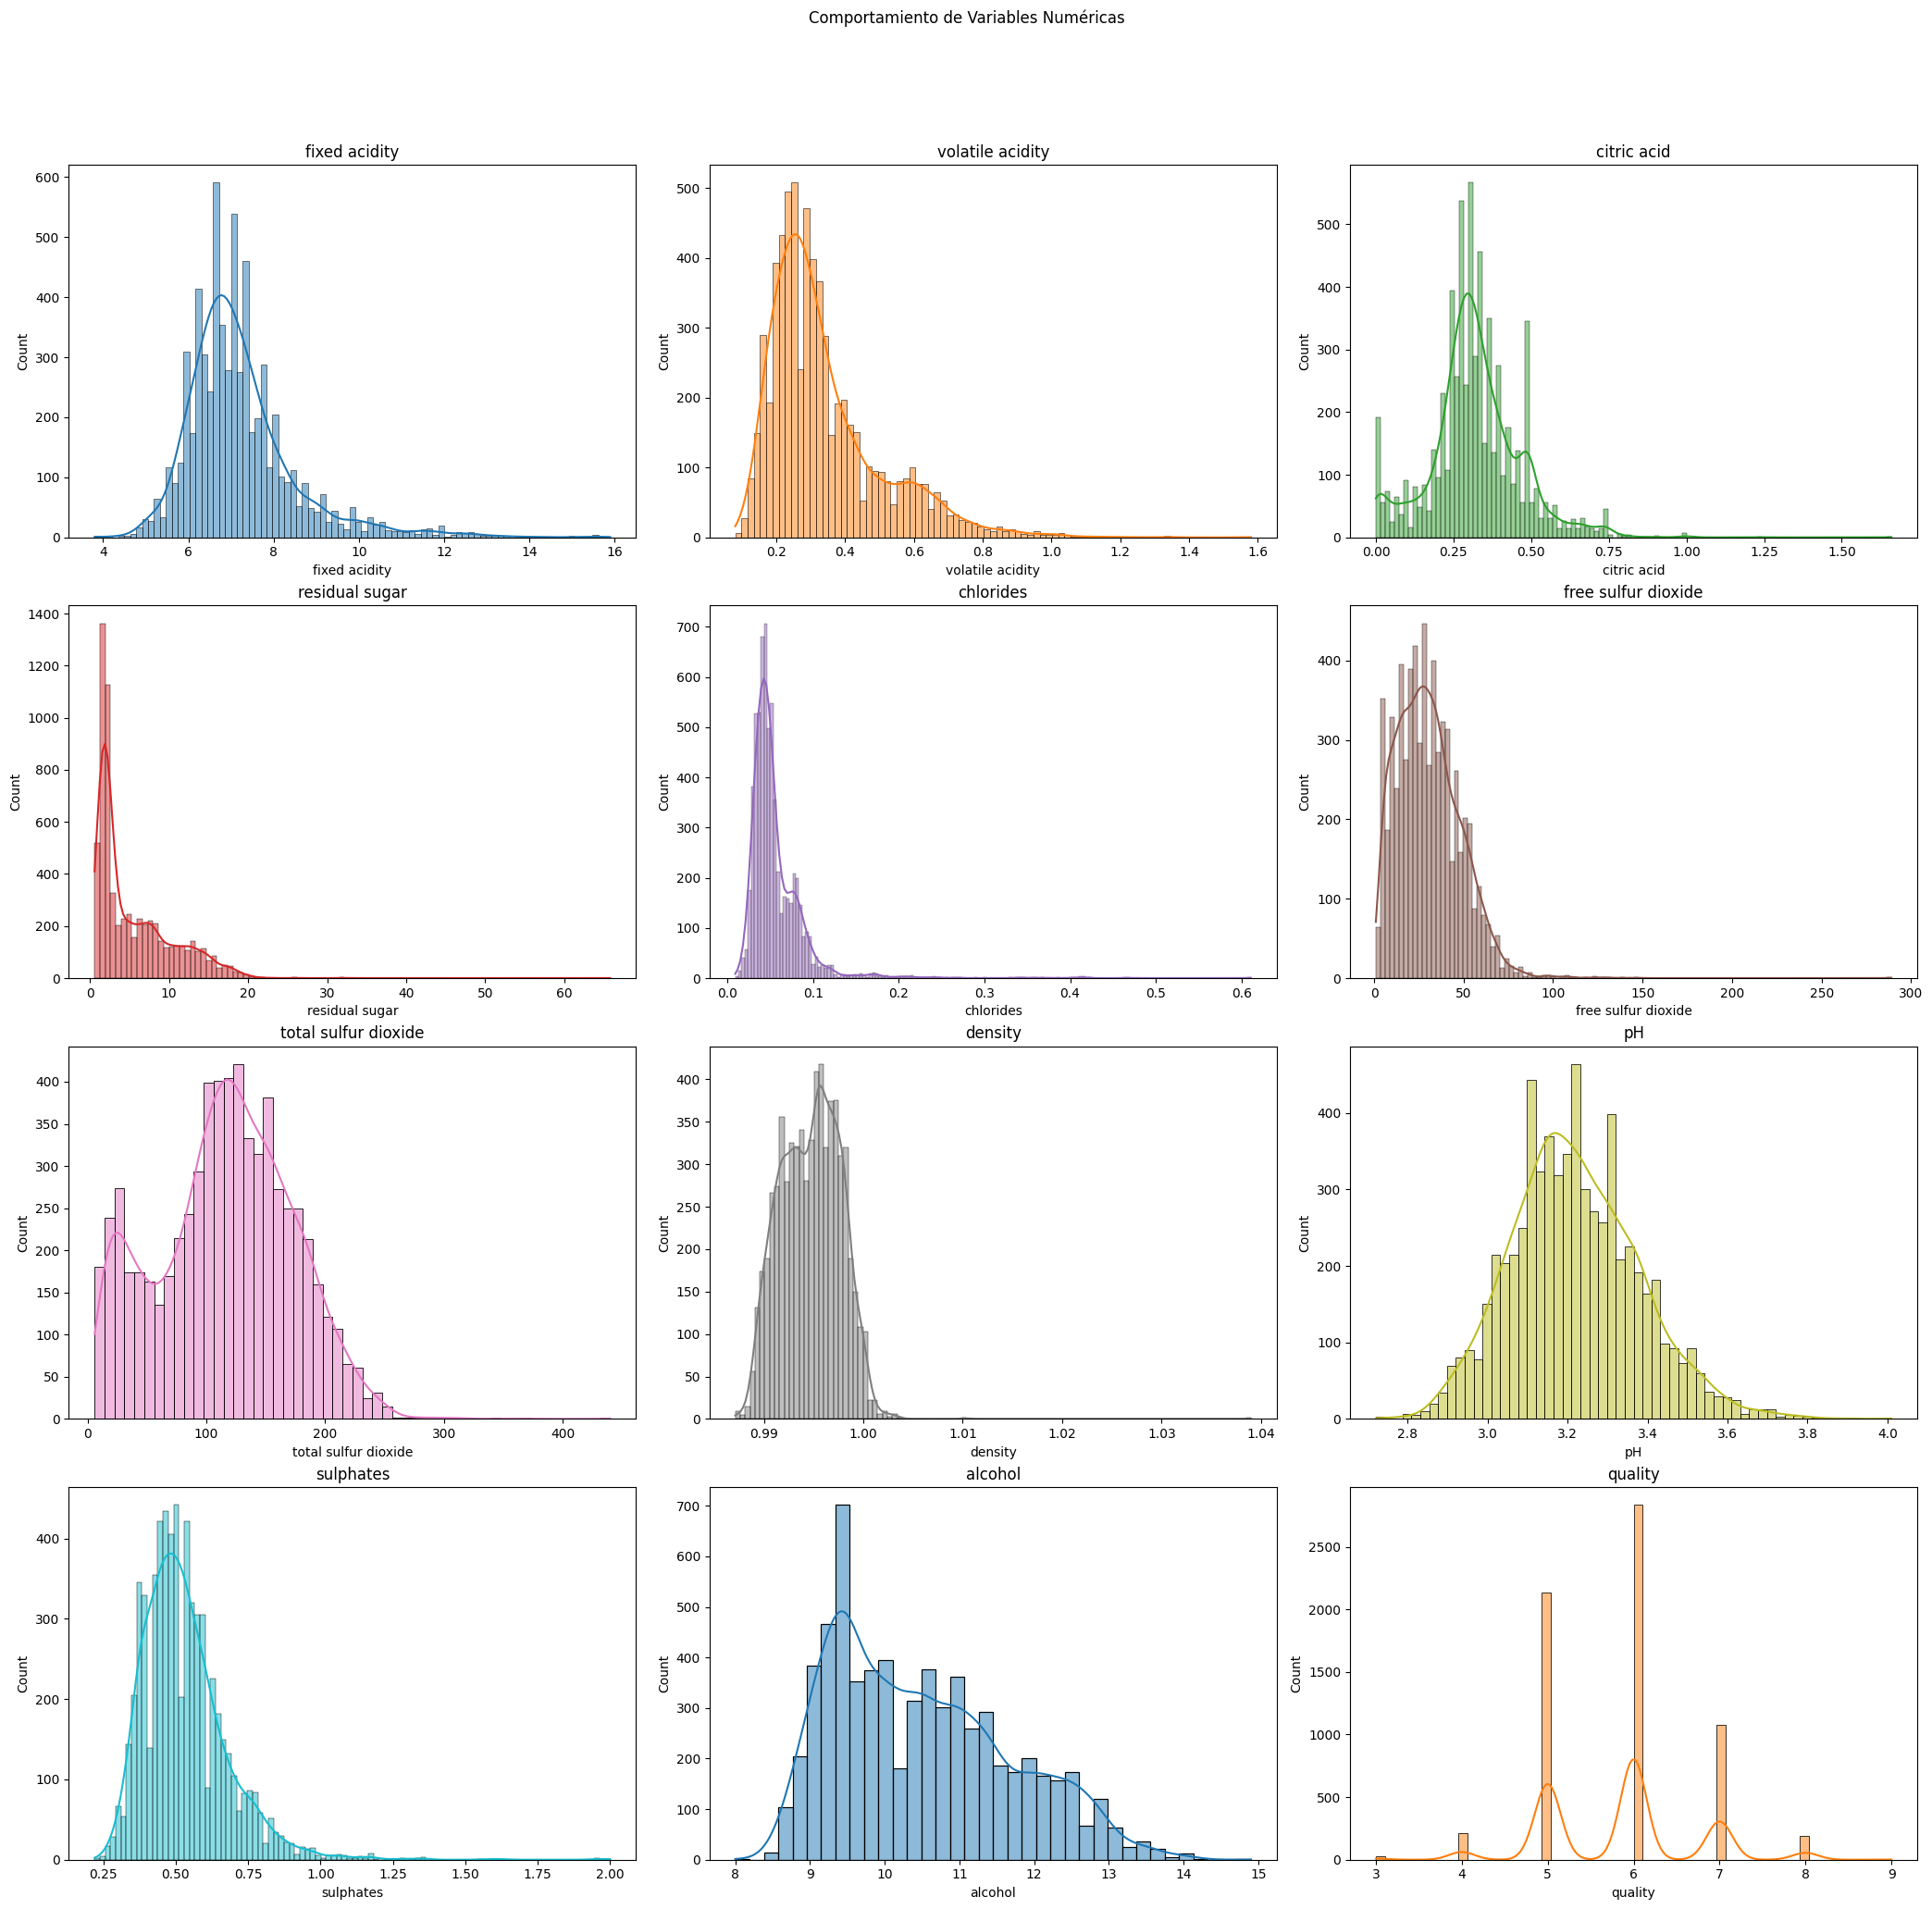

In [5]:
#Gráficos de Histogramas de frecuencia
fig, ax = plt.subplots(4, 3, figsize = (21,21))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.histplot(data = data, x = col, kde = True,
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

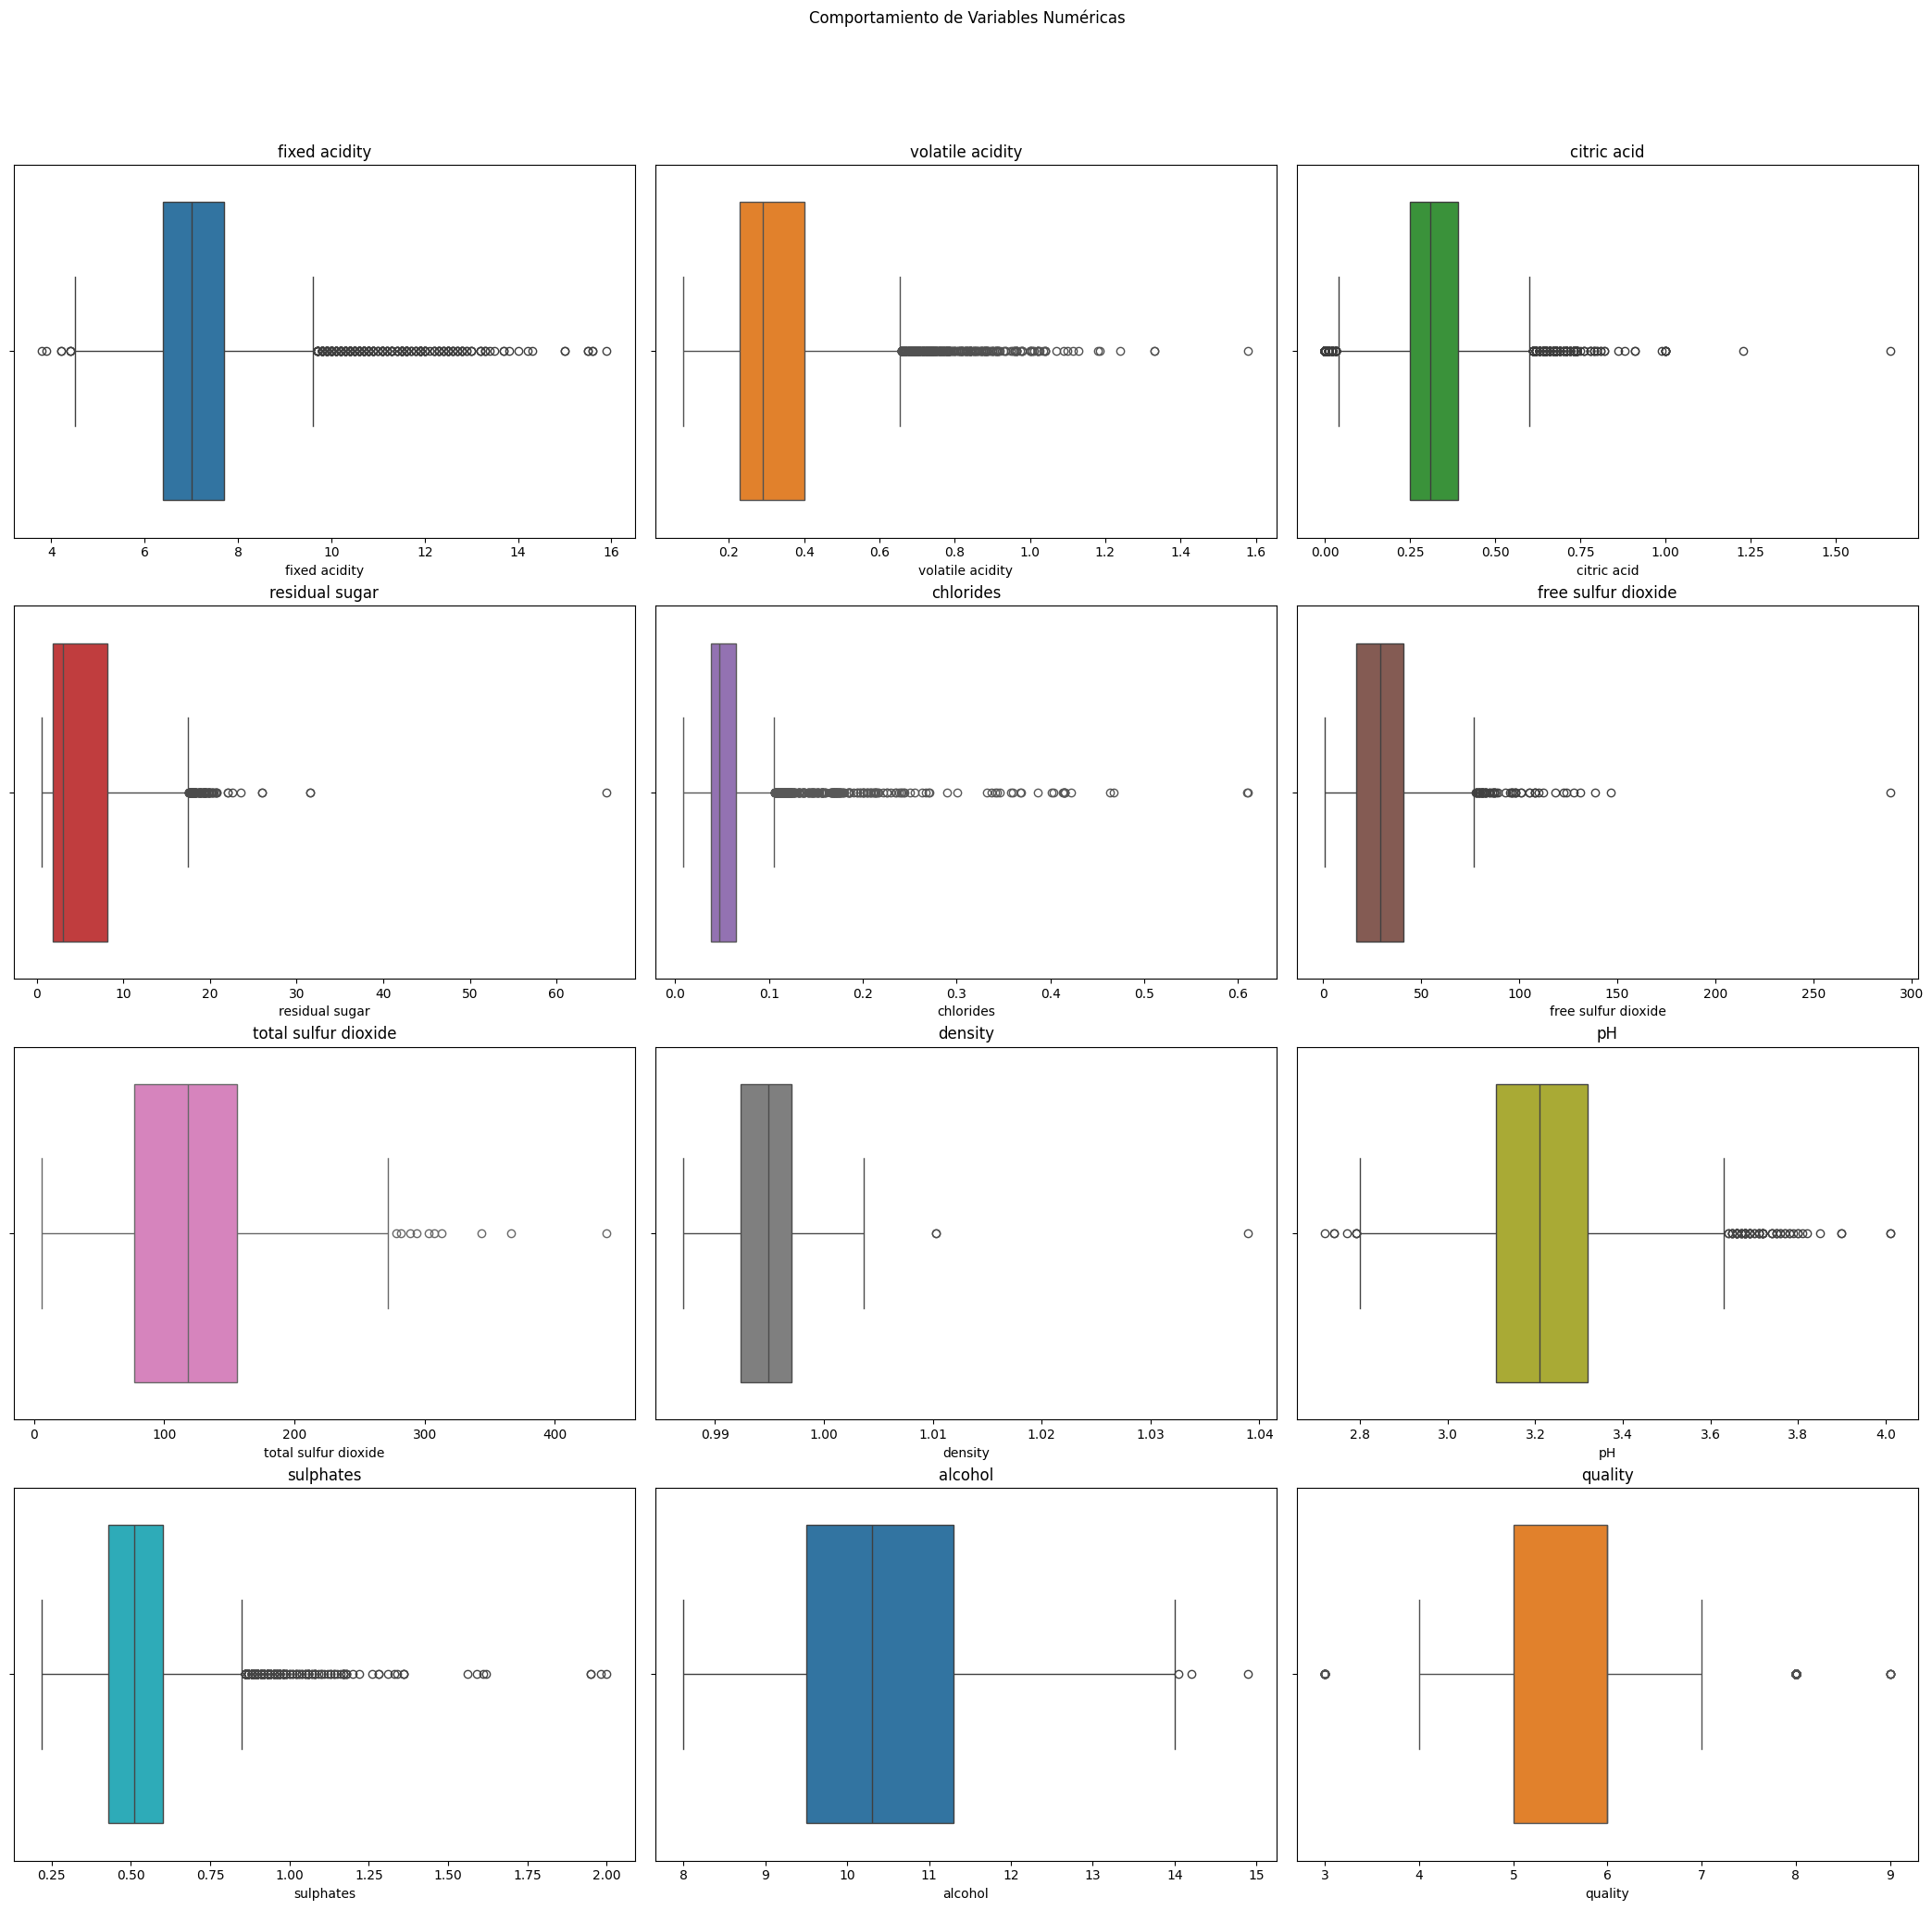

In [6]:
#Gráficos de Histogramas de frecuencia
fig, ax = plt.subplots(4, 3, figsize = (21,21))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.boxplot(data = data, x = col,
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

  ## Entendimiento de los datos:
- `fixed acidity`b: No tiene nulos implícitos porque según lo investigado, el valor máximo que tenemos de 15.9 es posible y representa un vino "ácido", que puede corresponder a algunos vinos de clima frio o a los que se les tuvo que añadir ácido para equilibrar el alto contenido en ázucar.
- `volatile acidity`: También dijimos que no tiene nulos implícitos porque a pesar de que el máximo permitido normalmente está entre 1.2g/L y 1.5g/L, hay algunas excepciones cuando el vino tiene alta azucar residual, donde volatile acidity puede llegar hasta 2.1g/L. Y el valor mínimo de 0.08 también es posible e indica una fermentación muy limpia, entonces también es un atípico natural.
- `citric acid`: Después de investigar, nos encontramos con que por ley, el máximo admisible es de 1g/L, entonces teniendo esto en cuenta y que solo eran dos valores que sobrepasaban el 1g/L, decidimos volverlos nulos explícitos.
- `residual sugar`: Del valor de ázucar residual hubo un único valor extremo que consideramos outlier antinatural, porque bajo el dataset, que se tratan vinos más tipo seco y semiseco, un valor tan alto no tiene sentido.
- `chlorides`: En esta concluimos que los atípicos eran naturales, porque según lo investigado, el límite máximo permitido es generalmente de 1g/L, que en nuestro caso, ningún dato sobrepasa esto.
- `free sulfur dioxide`: Para este vimos que los marcos legales dependían mucho del país, la mayoría rondando por los 70 y algo, pero el más alto que vimos fue de 80ppm, por tanto decidimos asumir como nulos, todos los que exedieran este valor. Y también de lo que vimos, valores muy altos rondando los 100ppm podrían estar hablando de barriles, en vez de vino terminado.
- `total sulfur dioxide`: Para esta variable cogimos el límite máximo legal permitido en Estados Unidos, que es de 350ppm, los dos valores que lo sobrepasaron, los convertimos a nulos.
- `density`: Aunque lo usual es que este entre 0.99g/mL a 0.995g/mL, al inicio de la fermentación pueden alcanzar a valores entre 1.09g/mL a 1.1g/mL y que los vinos dulces pueden tener una densidad más alta por los rangos de 1.05g/mL a 1.07g/mL, lo que hacía a nuestros atípicos posibles.
- `pH`: A pesar de que lo normal, es que el pH oscile entre 2.9 y 4, los outliers que tuvimos se acercaban mucho a estos valores \"que son lo normal\" y eran posibles.
- `sulphates`: Decidimos convertir a nulos los valores cercanos a 2g/L porque exceden el límite legal.
- `alcohol`: No decidimos eliminar ningún valor de alcohol porque el porcentage máximo es del 15%, mientras que nuestro valor máximo es 14.9%.

In [7]:
data_mod = data.copy()
data_mod.loc[data_mod['citric acid'] > 1, 'citric acid'] = np.nan
data_mod.loc[data_mod['residual sugar'] > 60, 'residual sugar'] = np.nan
data_mod.loc[data_mod['free sulfur dioxide'] > 80, 'free sulfur dioxide'] = np.nan
data_mod.loc[data_mod['total sulfur dioxide'] > 350, 'total sulfur dioxide'] = np.nan
data_mod.loc[data_mod['sulphates'] > 1.75, 'sulphates'] = np.nan
data_mod = data_mod.dropna()
data_mod.info()

<class 'pandas.DataFrame'>
Index: 6439 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6439 non-null   float64
 1   volatile acidity      6439 non-null   float64
 2   citric acid           6439 non-null   float64
 3   residual sugar        6439 non-null   float64
 4   chlorides             6439 non-null   float64
 5   free sulfur dioxide   6439 non-null   float64
 6   total sulfur dioxide  6439 non-null   float64
 7   density               6439 non-null   float64
 8   pH                    6439 non-null   float64
 9   sulphates             6439 non-null   float64
 10  alcohol               6439 non-null   float64
 11  quality               6439 non-null   int64  
 12  type                  6439 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 704.3 KB


In [8]:
pct_perdido = (6497 - 6439)/6497 * 100
print(f'El porcentaje de datos perdidos es: {pct_perdido:.2f}%, que es menor al 10% permitido, entonces se puede continuar y no hay necesidad de imputar.')

El porcentaje de datos perdidos es: 0.89%, que es menor al 10% permitido, entonces se puede continuar y no hay necesidad de imputar.


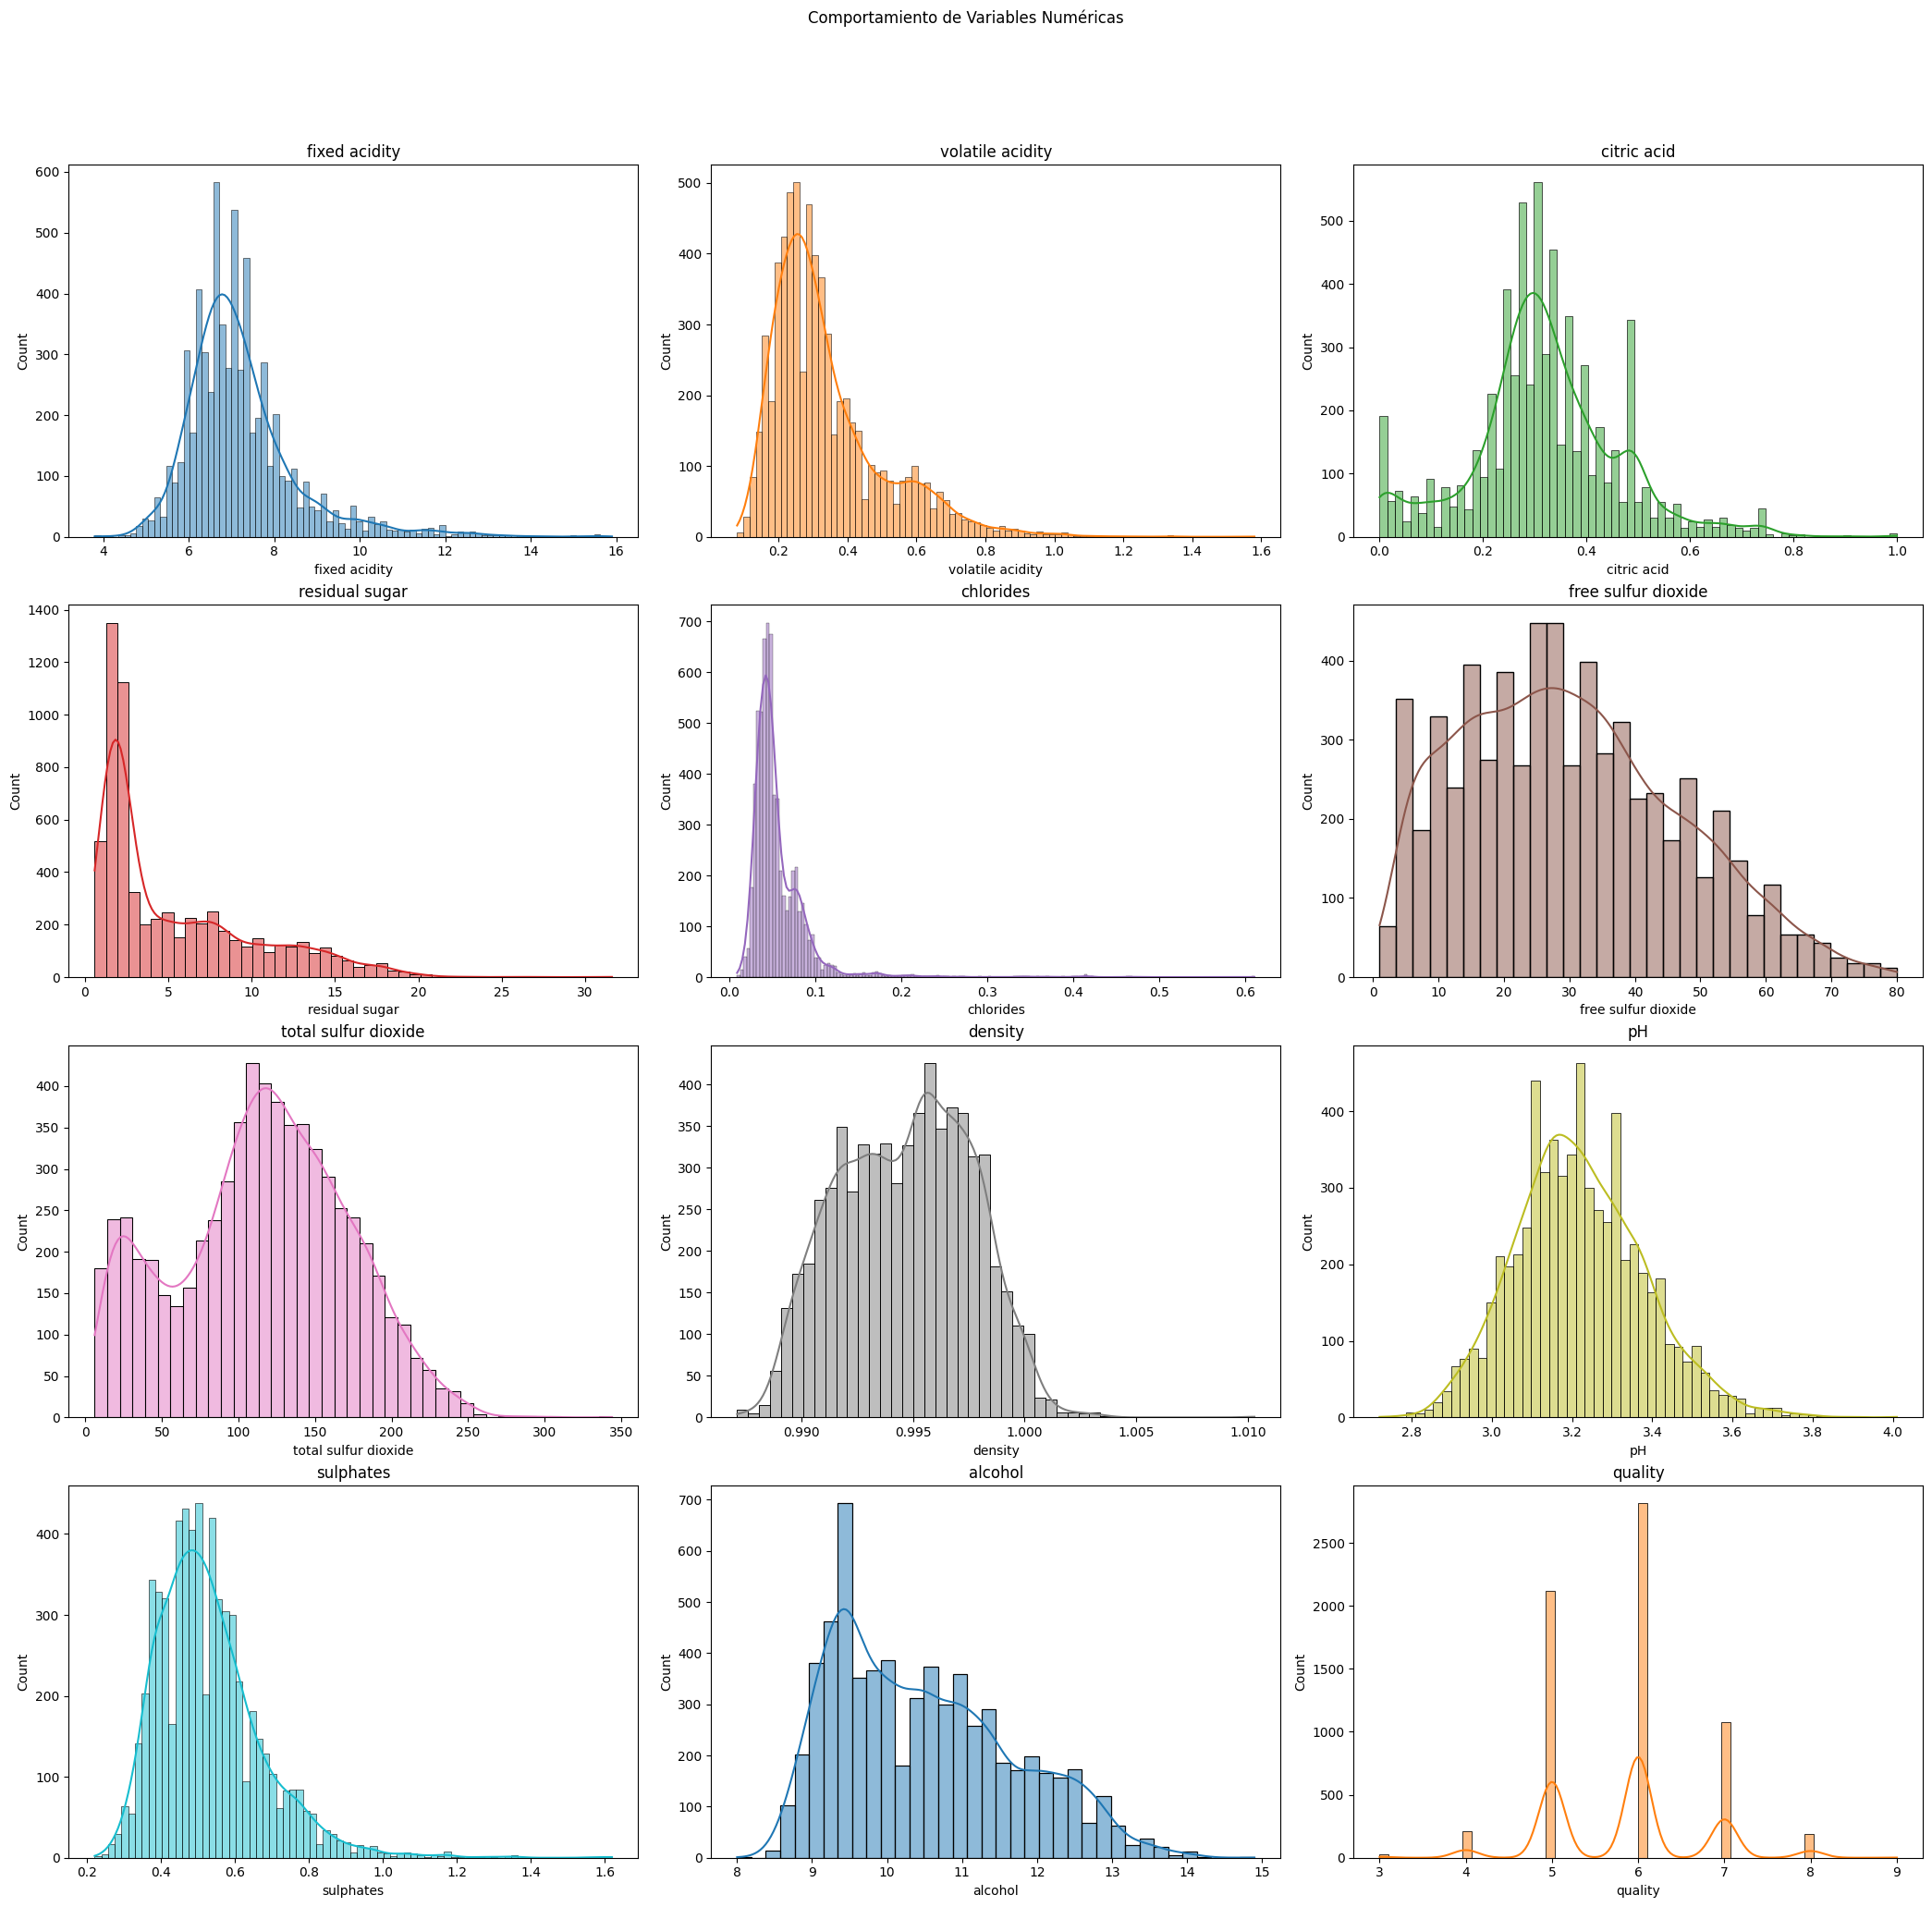

In [9]:
#Gráficos de Histogramas de frecuencia luego de la eliminación de atípicos
fig, ax = plt.subplots(4, 3, figsize = (21,21))
ax = ax.flat
num_col = data_mod.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sns.histplot(data = data_mod, x = col, kde = True,
                color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
                ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top=0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

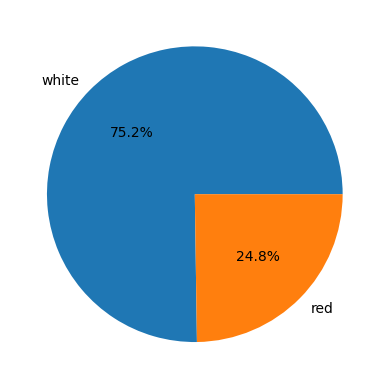

In [10]:
#Gáfico de Torta para la variable objetivo
plt.pie(x = data_mod['type'].value_counts(), labels = data_mod['type'].value_counts().index, autopct = '%0.1f%%')
plt.show()

In [11]:
#BALANCEO
data_red = data_mod[data_mod['type'] == 'red']
data_white = data_mod[data_mod['type'] == 'white']
print(f'El tamaño de la clase red es: {data_red.shape}\n El tamaño de la clase white es: {data_white.shape}')

El tamaño de la clase red es: (1595, 13)
 El tamaño de la clase white es: (4844, 13)


In [12]:
data_red_re = data_red.sample(data_white.shape[0], replace=True)
data_balanced = pd.concat([data_white, data_red_re])
data_balanced.reset_index(drop = True, inplace=True)
data_balanced.info()

<class 'pandas.DataFrame'>
RangeIndex: 9688 entries, 0 to 9687
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         9688 non-null   float64
 1   volatile acidity      9688 non-null   float64
 2   citric acid           9688 non-null   float64
 3   residual sugar        9688 non-null   float64
 4   chlorides             9688 non-null   float64
 5   free sulfur dioxide   9688 non-null   float64
 6   total sulfur dioxide  9688 non-null   float64
 7   density               9688 non-null   float64
 8   pH                    9688 non-null   float64
 9   sulphates             9688 non-null   float64
 10  alcohol               9688 non-null   float64
 11  quality               9688 non-null   int64  
 12  type                  9688 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 984.1 KB


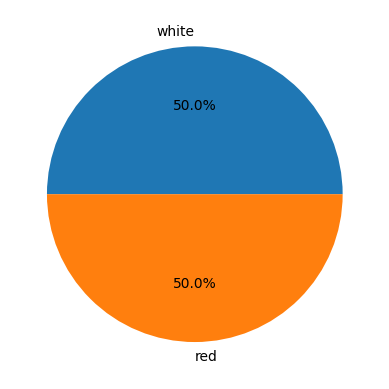

In [13]:
plt.pie(x = data_balanced['type'].value_counts(), labels = data_balanced['type'].value_counts().index, autopct = '%0.1f%%')
plt.show()

In [14]:
data_X = data_balanced.drop(columns='type')
data_y = data_balanced[['type']]

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = data_X.select_dtypes(include= ['int64','float64']).columns.to_list()
num_transformer1 = Pipeline(steps=[('scaler', MinMaxScaler())])
preprocessor1 = ColumnTransformer(transformers=[('num', num_transformer1, num_cols)], remainder='passthrough')
preprocessor1

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fea

In [16]:
data_X_pre1 = preprocessor1.fit_transform(data_X)
data_X_pro1 = pd.DataFrame(data_X_pre1, columns= num_cols)
data_X_pro1

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.264463,0.126667,0.36,0.648387,0.059801,0.556962,0.485207,0.598965,0.217054,0.164286,0.115942,0.500000
1,0.206612,0.146667,0.34,0.032258,0.066445,0.164557,0.372781,0.297111,0.449612,0.192857,0.217391,0.500000
2,0.355372,0.133333,0.40,0.203226,0.068106,0.367089,0.269231,0.344545,0.418605,0.157143,0.304348,0.500000
3,0.280992,0.100000,0.32,0.254839,0.081395,0.582278,0.532544,0.366106,0.364341,0.128571,0.275362,0.500000
4,0.280992,0.100000,0.32,0.254839,0.081395,0.582278,0.532544,0.366106,0.364341,0.128571,0.275362,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...
9683,0.148760,0.153333,0.78,0.429032,0.107973,0.278481,0.254438,0.416559,0.519380,0.185714,0.362319,0.500000
9684,0.537190,0.173333,0.52,0.070968,0.249169,0.177215,0.204142,0.547219,0.356589,0.300000,0.202899,0.333333
9685,0.528926,0.393333,0.39,0.041935,0.074751,0.063291,0.032544,0.452350,0.348837,0.178571,0.289855,0.333333
9686,0.471074,0.320000,0.33,0.058065,0.132890,0.430380,0.180473,0.435101,0.434109,0.364286,0.550725,0.666667


In [17]:
num_transformer2 = Pipeline(steps=[('scaler', StandardScaler())])
preprocessor2 = ColumnTransformer(transformers=[('num', num_transformer2, num_cols)], remainder='passthrough')
preprocessor2

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{fea

In [18]:
data_X_pre2 = preprocessor2.fit_transform(data_X)
data_X_pro2 = pd.DataFrame(data_X_pre2, columns= num_cols)
data_X_pro2

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,-0.368376,-0.695420,0.365220,3.927145,-0.534357,1.231522,1.323803,1.997414,-1.522803,-0.771466,-1.437674,0.284844
1,-0.816186,-0.539398,0.243142,-0.689019,-0.432746,-0.687797,0.683059,-0.489697,0.296157,-0.517301,-0.833584,0.284844
2,0.335326,-0.643412,0.609377,0.591906,-0.407344,0.302819,0.092899,-0.098865,0.053629,-0.835007,-0.315792,0.284844
3,-0.240430,-0.903449,0.121064,0.978601,-0.204122,1.355349,1.593590,0.078785,-0.370795,-1.089172,-0.488389,0.284844
4,-0.240430,-0.903449,0.121064,0.978601,-0.204122,1.355349,1.593590,0.078785,-0.370795,-1.089172,-0.488389,0.284844
...,...,...,...,...,...,...,...,...,...,...,...,...
9683,-1.263996,-0.487391,2.928863,2.283694,0.202323,-0.130576,0.008591,0.494488,0.841844,-0.580843,0.029402,0.284844
9684,1.742730,-0.331369,1.341846,-0.398998,2.361558,-0.625884,-0.278058,1.571052,-0.431427,0.435816,-0.919882,-0.885954
9685,1.678757,1.384870,0.548338,-0.616514,-0.305733,-1.183106,-1.256036,0.789389,-0.492059,-0.644384,-0.402091,-0.885954
9686,1.230947,0.812790,0.182103,-0.495672,0.583364,0.612387,-0.412951,0.647268,0.174893,1.007686,1.151283,1.455643


In [19]:
import sklearn
from sklearn.preprocessing import OrdinalEncoder
categorical_cols = data_y.select_dtypes(include= 'object').columns
categorical_transformer = sklearn.compose.make_column_transformer((OrdinalEncoder(), categorical_cols),
                                                                 remainder = 'passthrough')
categorical_transformer

C:\Users\migue\AppData\Local\Temp\ipykernel_10868\411377590.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = data_y.select_dtypes(include= 'object').columns


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('ordinalencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.

In [20]:
data_transformed = pd.DataFrame(categorical_transformer.fit_transform(data_y),
                                columns=categorical_transformer.get_feature_names_out(),
                                index=data_y.index).rename(columns= lambda x: x.removeprefix('ordinalencoder__')).rename(columns= lambda x: x.removeprefix('remainder__'))
data_transformed

,type
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
9683,0.0
9684,0.0
9685,0.0
9686,0.0


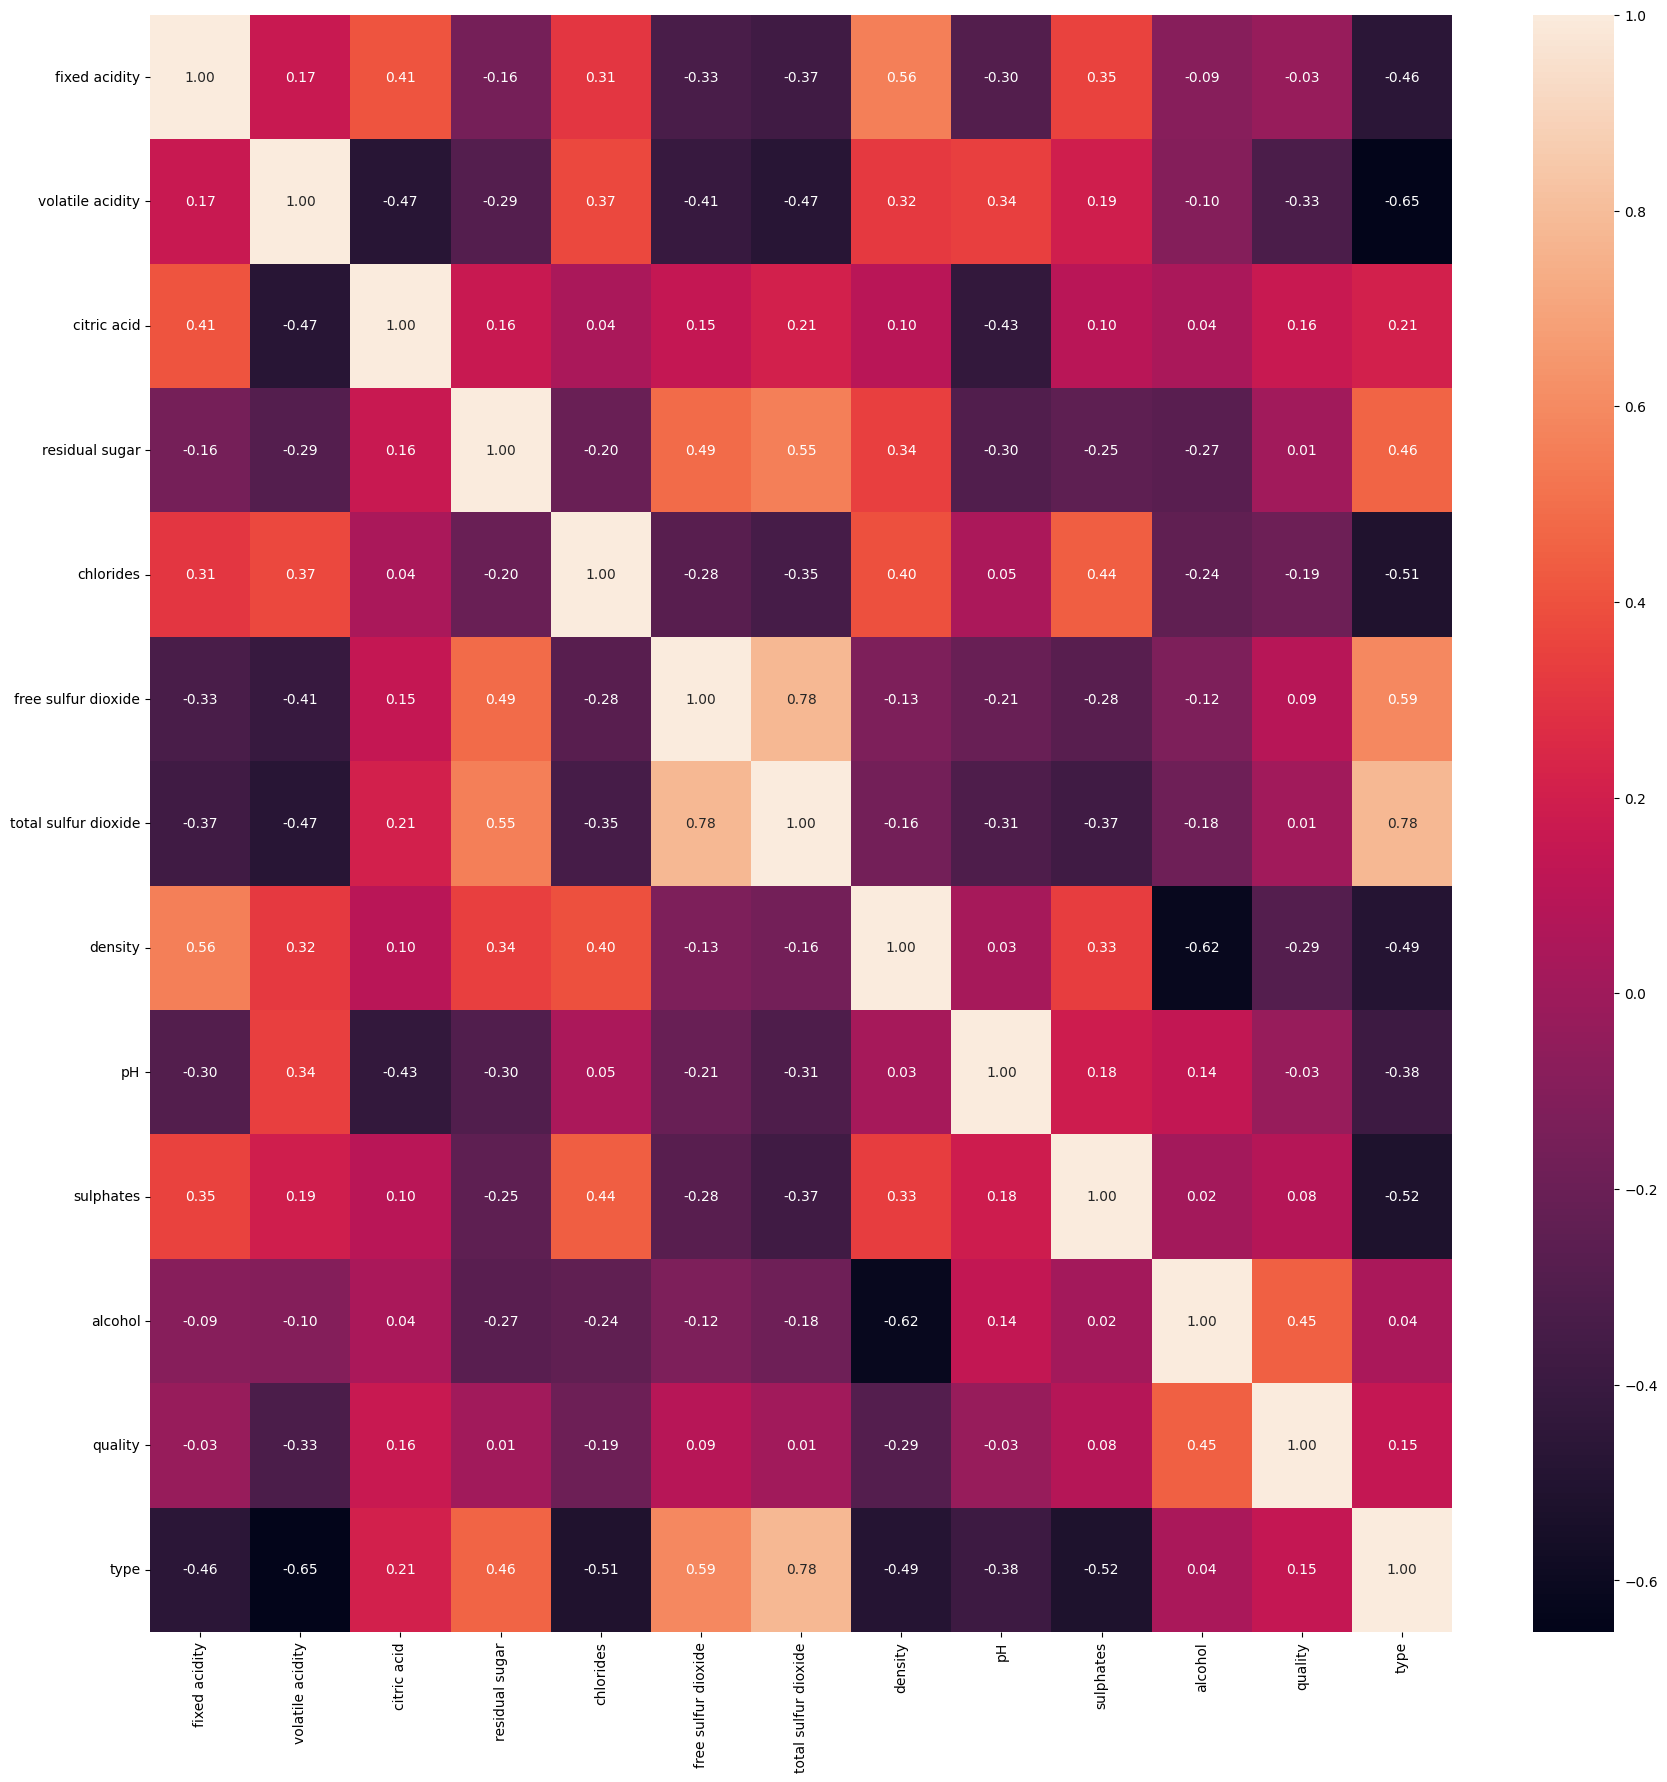

In [21]:
prueba = pd.concat([data_X_pro2, data_transformed], axis=1)

plt.figure(figsize= (21,21))
sns.heatmap(data=prueba.corr(numeric_only= True), annot= True, fmt= '0.2f')
plt.show()

## Prueba con modelo base para seleccionar estandarizacion o normalizacion

In [22]:
from sklearn.model_selection import train_test_split
X_trainN, X_testN, y_trainN, y_testN = train_test_split(data_X_pro1, data_y, train_size=0.7, random_state=32)
X_trainE, X_testE, y_trainE, y_testE = train_test_split(data_X_pro2, data_y, train_size=0.7, random_state=32)
print(f'El tamaño del conjunto de entrenamiento normalizado es: {X_trainN.shape} {y_trainN.shape}\ny el tamaño del conjunto de validacion normalizado es {X_testN.shape, y_testN.shape}')
print(f'El tamaño del conjunto de entrenamiento estandarizado es: {X_trainE.shape} {y_trainE.shape}\ny el tamaño del conjunto de validacion estandarizado es {X_testE.shape, y_testE.shape}')

El tamaño del conjunto de entrenamiento normalizado es: (6781, 12) (6781, 1)
y el tamaño del conjunto de validacion normalizado es ((2907, 12), (2907, 1))
El tamaño del conjunto de entrenamiento estandarizado es: (6781, 12) (6781, 1)
y el tamaño del conjunto de validacion estandarizado es ((2907, 12), (2907, 1))


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
modelN1 = DecisionTreeClassifier(random_state=32)
modelN2 = KNeighborsClassifier()
modelE1 = DecisionTreeClassifier(random_state=32)
modelE2 = KNeighborsClassifier()
modelN1.fit(X_trainN, y_trainN)
modelN2.fit(X_trainN, y_trainN)
modelE1.fit(X_trainE, y_trainE)
modelE2.fit(X_trainE, y_trainE)
pred1N = modelN1.predict(X_testN)
pred2N = modelN2.predict(X_testN)
pred1E = modelE1.predict(X_testE)
pred2E = modelE2.predict(X_testE)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_testN, pred1N))
print(classification_report(y_testE, pred1E))

              precision    recall  f1-score   support

         red       0.99      0.99      0.99      1513
       white       0.99      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907

              precision    recall  f1-score   support

         red       0.99      0.99      0.99      1513
       white       0.99      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907



In [25]:
print(classification_report(y_testN, pred2N))
print(classification_report(y_testE, pred2E))

              precision    recall  f1-score   support

         red       0.99      1.00      0.99      1513
       white       0.99      0.99      0.99      1394

    accuracy                           0.99      2907
   macro avg       0.99      0.99      0.99      2907
weighted avg       0.99      0.99      0.99      2907

              precision    recall  f1-score   support

         red       0.99      1.00      1.00      1513
       white       1.00      0.99      0.99      1394

    accuracy                           1.00      2907
   macro avg       1.00      1.00      1.00      2907
weighted avg       1.00      1.00      1.00      2907



In [26]:
print("Train scores:")
print(f"DecisionTree Norm: {modelN1.score(X_trainN, y_trainN):.4f}")
print(f"DecisionTree Est:  {modelE1.score(X_trainE, y_trainE):.4f}")

print("\nTest scores:")
print(f"DecisionTree Norm: {modelN1.score(X_testN, y_testN):.4f}")
print(f"DecisionTree Est:  {modelE1.score(X_testE, y_testE):.4f}")

Train scores:
DecisionTree Norm: 0.9999
DecisionTree Est:  0.9999

Test scores:
DecisionTree Norm: 0.9914
DecisionTree Est:  0.9914


Se decidió usar el MinMaxScaler() LOS QUE TIENEN N

## Ajuste de Hiperparametros para los 10 modelos a probar
- Naive Bayes
- Regresión Logística
- K vecinos Más Cercanos
- Máquina de Soporte Vectorial
- Árbol de Decisión
- Extra Tree Classifier
- Random Forest
- Adaptative Boosting
- Gradient Boosting 
- Red Neuronal Artificial

In [27]:
scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

In [28]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
model_1 = GaussianNB()
param_grid = {
    'var_smoothing': np.logspace(0,-9, num=100)
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf1 = GridSearchCV(estimator=model_1,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf1.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.",{'var_smoothing': array([1.0000...00000000e-09])}
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more message

In [29]:
cv_results = pd.DataFrame(clf1.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_var_smoothing,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,split3_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
12,0.010089,0.002207,0.045748,0.010383,0.081113,{'var_smoothing': 0.08111308307896872},0.976419,0.980088,0.971976,0.973451,...,0.002872,1,0.976409,0.980083,0.971949,0.973443,0.974186,0.975214,0.002828,1
17,0.021013,0.028901,0.040217,0.015333,0.028480,{'var_smoothing': 0.02848035868435802},0.974945,0.978614,0.971976,0.977139,...,0.002614,2,0.974938,0.978612,0.971949,0.977134,0.972711,0.975069,0.002535,2
16,0.008179,0.002279,0.037480,0.009570,0.035112,{'var_smoothing': 0.03511191734215131},0.974945,0.980088,0.971239,0.974926,...,0.003085,3,0.974938,0.980086,0.971210,0.974921,0.972711,0.974773,0.003007,3
11,0.007944,0.002388,0.058435,0.044907,0.100000,{'var_smoothing': 0.1},0.975682,0.980088,0.971239,0.971976,...,0.003204,4,0.975673,0.980083,0.971213,0.971966,0.974186,0.974624,0.003156,4
13,0.007468,0.001647,0.033353,0.005475,0.065793,{'var_smoothing': 0.0657933224657568},0.974208,0.979351,0.971976,0.973451,...,0.002586,5,0.974197,0.979346,0.971949,0.973444,0.973448,0.974477,0.002541,5
18,0.018453,0.017425,0.047590,0.004271,0.023101,{'var_smoothing': 0.02310129700083159},0.973471,0.976401,0.971976,0.976401,...,0.001946,6,0.973462,0.976399,0.971952,0.976397,0.972711,0.974184,0.001869,6
14,0.010733,0.004636,0.043567,0.009657,0.053367,{'var_smoothing': 0.0533669923120631},0.974208,0.979351,0.971976,0.973451,...,0.002745,7,0.974200,0.979346,0.971949,0.973444,0.971974,0.974183,0.002723,7
10,0.030160,0.042658,0.045746,0.011313,0.123285,{'var_smoothing': 0.12328467394420659},0.974945,0.980088,0.971239,0.971239,...,0.003308,8,0.974935,0.980083,0.971213,0.971229,0.973448,0.974181,0.003270,8
15,0.015494,0.016509,0.051805,0.017463,0.043288,{'var_smoothing': 0.04328761281083057},0.974945,0.977876,0.971976,0.973451,...,0.002248,9,0.974938,0.977872,0.971952,0.973444,0.971974,0.974036,0.002212,9
20,0.013185,0.004857,0.060575,0.024954,0.015199,{'var_smoothing': 0.01519911082952933},0.974208,0.975664,0.970501,0.974926,...,0.002007,10,0.974200,0.975661,0.970478,0.974922,0.971973,0.973447,0.001930,10


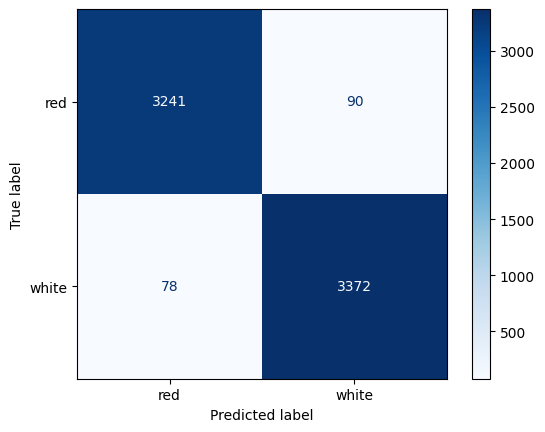

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import cross_val_predict
labels = data['type'].unique()

best_clf1 = clf1.best_estimator_
y_train_pred = cross_val_predict(best_clf1, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val = confusion_matrix(y_trainN, y_train_pred)
ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels).plot(cmap=plt.cm.Blues)

In [31]:
#Regresión Logística
from sklearn.linear_model import LogisticRegression
model_2 = LogisticRegression(solver= 'saga', random_state=32)
param_grid = {
    'penalty':['l1','l2','elasticnet'],
    'C':[0.001, 0.01, 0.1,1,10,100,1000]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf2 = GridSearchCV(estimator=model_2,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf2.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\linear_model\_sag

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...solver='saga')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: th

In [32]:
cv_results2 = pd.DataFrame(clf2.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results2.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_penalty,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
9,0.262676,0.052404,0.035945,0.010934,1.0,l1,"{'C': 1, 'penalty': 'l1'}",0.994842,0.994838,0.989676,...,0.001947,1,0.994839,0.994836,0.989672,0.992623,0.994098,0.993214,0.001947,1
13,0.130410,0.016050,0.065307,0.024970,10.0,l2,"{'C': 10, 'penalty': 'l2'}",0.994842,0.994838,0.989676,...,0.002012,2,0.994839,0.994836,0.989672,0.991885,0.994098,0.993066,0.002013,2
14,0.132238,0.056904,0.046937,0.019909,10.0,elasticnet,"{'C': 10, 'penalty': 'elasticnet'}",0.994842,0.994838,0.989676,...,0.002012,2,0.994839,0.994836,0.989672,0.991885,0.994098,0.993066,0.002013,2
12,0.172808,0.011355,0.060360,0.008273,10.0,l1,"{'C': 10, 'penalty': 'l1'}",0.994842,0.994100,0.989676,...,0.001840,4,0.994839,0.994098,0.989672,0.992623,0.994098,0.993066,0.001844,4
18,0.162563,0.035340,0.042494,0.006157,1000.0,l1,"{'C': 1000, 'penalty': 'l1'}",0.994842,0.994100,0.989676,...,0.001840,4,0.994839,0.994098,0.989672,0.992623,0.994098,0.993066,0.001844,4
19,0.132413,0.023930,0.037283,0.004157,1000.0,l2,"{'C': 1000, 'penalty': 'l2'}",0.994842,0.994100,0.989676,...,0.001840,4,0.994839,0.994098,0.989672,0.992623,0.994098,0.993066,0.001844,4
15,0.209589,0.076061,0.065268,0.035833,100.0,l1,"{'C': 100, 'penalty': 'l1'}",0.994842,0.994100,0.989676,...,0.001840,4,0.994839,0.994098,0.989672,0.992623,0.994098,0.993066,0.001844,4
20,0.124516,0.011540,0.032790,0.010391,1000.0,elasticnet,"{'C': 1000, 'penalty': 'elasticnet'}",0.994842,0.994100,0.989676,...,0.001840,4,0.994839,0.994098,0.989672,0.992623,0.994098,0.993066,0.001844,4
16,0.131586,0.046610,0.057015,0.033432,100.0,l2,"{'C': 100, 'penalty': 'l2'}",0.994842,0.994100,0.988938,...,0.002150,9,0.994839,0.994098,0.988934,0.991885,0.994098,0.992771,0.002159,9
17,0.217198,0.092774,0.048539,0.024701,100.0,elasticnet,"{'C': 100, 'penalty': 'elasticnet'}",0.994842,0.994100,0.988938,...,0.002150,9,0.994839,0.994098,0.988934,0.991885,0.994098,0.992771,0.002159,9


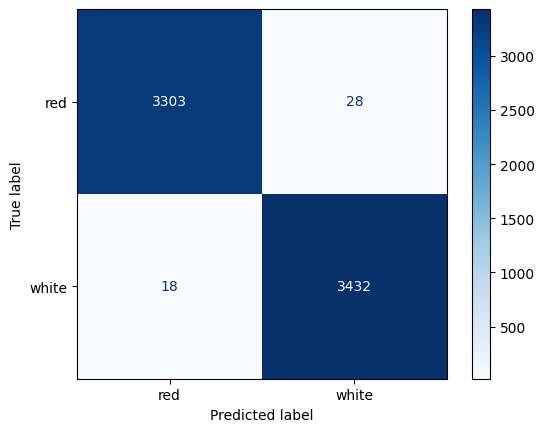

In [33]:
best_clf2 = clf2.best_estimator_
y_train_pred2 = cross_val_predict(best_clf2, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val2 = confusion_matrix(y_trainN, y_train_pred2)
ConfusionMatrixDisplay(confusion_matrix=cm_val2, display_labels=labels).plot(cmap=plt.cm.Blues)

In [34]:
#k vecinos mas cercanos
from sklearn.neighbors import KNeighborsClassifier
model_3 = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3,5,7,9,11,15,101],
    'p':[1,2]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf3 = GridSearchCV(estimator=model_3,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf3.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...], 'p': [1, 2]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more mes

In [35]:
cv_results3 = pd.DataFrame(clf3.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results3.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_p,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
0,0.029964,0.026720,0.158958,0.054405,3,1,"{'n_neighbors': 3, 'p': 1}",0.995578,0.994838,0.991888,...,0.002204,1,0.995577,0.994837,0.991886,0.989674,0.991149,0.992625,0.002238,1
2,0.035171,0.023160,0.262618,0.049562,5,1,"{'n_neighbors': 5, 'p': 1}",0.994842,0.992625,0.991150,...,0.003416,2,0.994840,0.992624,0.991147,0.984511,0.990411,0.990707,0.003448,2
6,0.017074,0.003776,0.228875,0.069550,9,1,"{'n_neighbors': 9, 'p': 1}",0.991894,0.993363,0.989676,...,0.002251,3,0.991891,0.993361,0.989671,0.986722,0.990411,0.990411,0.002239,3
4,0.019748,0.003113,0.148433,0.023759,7,1,"{'n_neighbors': 7, 'p': 1}",0.991894,0.993363,0.990413,...,0.002479,4,0.991891,0.993361,0.990409,0.985985,0.989673,0.990264,0.002487,4
1,0.041161,0.026579,0.156499,0.024907,3,2,"{'n_neighbors': 3, 'p': 2}",0.990420,0.994100,0.989676,...,0.002188,5,0.990419,0.994099,0.989673,0.988936,0.987462,0.990118,0.002217,5
8,0.043949,0.042755,0.243722,0.053068,11,1,"{'n_neighbors': 11, 'p': 1}",0.990420,0.992625,0.988201,...,0.002065,6,0.990418,0.992624,0.988195,0.986722,0.990411,0.989674,0.002035,6
10,0.015751,0.003299,0.200483,0.041088,15,1,"{'n_neighbors': 15, 'p': 1}",0.991157,0.991888,0.988201,...,0.002149,7,0.991154,0.991886,0.988195,0.985983,0.989673,0.989378,0.002119,7
3,0.033143,0.023310,0.173709,0.025105,5,2,"{'n_neighbors': 5, 'p': 2}",0.991157,0.991888,0.988201,...,0.002157,8,0.991155,0.991886,0.988197,0.985985,0.988199,0.989085,0.002159,8
5,0.018588,0.002833,0.211053,0.084137,7,2,"{'n_neighbors': 7, 'p': 2}",0.991894,0.991150,0.986726,...,0.003010,9,0.991891,0.991149,0.986720,0.983772,0.989673,0.988641,0.003010,9
12,0.031472,0.027382,0.201902,0.033598,101,1,"{'n_neighbors': 101, 'p': 1}",0.989683,0.990413,0.987463,...,0.001386,10,0.989681,0.990411,0.987457,0.986722,0.988198,0.988494,0.001370,10


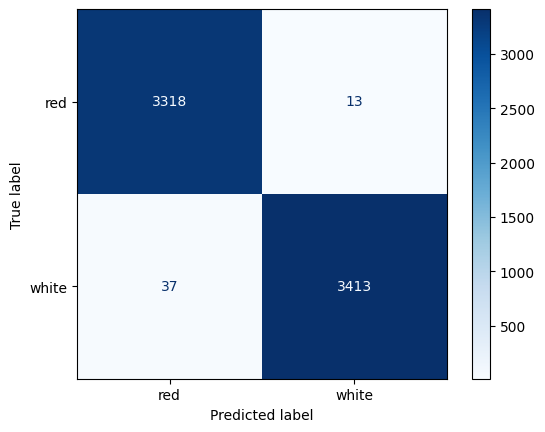

In [36]:
best_clf3 = clf3.best_estimator_
y_train_pred3 = cross_val_predict(best_clf3, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val3 = confusion_matrix(y_trainN, y_train_pred3)
ConfusionMatrixDisplay(confusion_matrix=cm_val3, display_labels=labels).plot(cmap=plt.cm.Blues)

In [37]:
#Maquina de soporte vectorial
from sklearn.svm import SVC
model_4 = SVC(random_state=32)
param_grid = {
    'C': [0.001, 0.01, 0.1, 10, 100],
    'kernel': ['poly', 'linear', 'rbf', 'sigmoid'],
    'degree': [2,3]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf4 = GridSearchCV(estimator=model_4,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf4.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=32)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.001, 0.01, ...], 'degree': [2, 3], 'kernel': ['poly', 'linear', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the 

In [38]:
cv_results4 = pd.DataFrame(clf4.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results4.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_degree,param_kernel,params,split0_test_accuracy,split1_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
38,0.137938,0.028329,0.099701,0.030113,100.00,3,rbf,"{'C': 100, 'degree': 3, 'kernel': 'rbf'}",0.997789,0.997050,...,0.000975,1,0.997788,0.997050,0.997787,0.995574,0.995574,0.996755,0.001001,1
34,0.153966,0.030515,0.129287,0.053543,100.00,2,rbf,"{'C': 100, 'degree': 2, 'kernel': 'rbf'}",0.997789,0.997050,...,0.000975,1,0.997788,0.997050,0.997787,0.995574,0.995574,0.996755,0.001001,1
28,0.277228,0.067174,0.087993,0.008741,10.00,3,poly,"{'C': 10, 'degree': 3, 'kernel': 'poly'}",0.997052,0.995575,...,0.001148,3,0.997051,0.995574,0.995574,0.995574,0.993362,0.995427,0.001181,3
26,0.147523,0.012556,0.111205,0.008564,10.00,2,rbf,"{'C': 10, 'degree': 2, 'kernel': 'rbf'}",0.996315,0.994838,...,0.001068,4,0.996314,0.994836,0.997049,0.994098,0.994836,0.995427,0.001085,4
30,0.125974,0.026720,0.101859,0.020958,10.00,3,rbf,"{'C': 10, 'degree': 3, 'kernel': 'rbf'}",0.996315,0.994838,...,0.001068,4,0.996314,0.994836,0.997049,0.994098,0.994836,0.995427,0.001085,4
36,0.585145,0.205670,0.070370,0.010306,100.00,3,poly,"{'C': 100, 'degree': 3, 'kernel': 'poly'}",0.997052,0.991888,...,0.001743,6,0.997051,0.991887,0.996312,0.995574,0.994837,0.995132,0.001783,6
24,0.173506,0.029546,0.075628,0.013363,10.00,2,poly,"{'C': 10, 'degree': 2, 'kernel': 'poly'}",0.996315,0.994838,...,0.000846,7,0.996314,0.994836,0.995573,0.994098,0.994098,0.994984,0.000861,7
20,0.121648,0.014502,0.089081,0.005913,0.10,3,poly,"{'C': 0.1, 'degree': 3, 'kernel': 'poly'}",0.995578,0.994838,...,0.001435,8,0.995576,0.994836,0.991884,0.993360,0.995573,0.994246,0.001431,8
32,0.613400,0.145364,0.089537,0.006579,100.00,2,poly,"{'C': 100, 'degree': 2, 'kernel': 'poly'}",0.994842,0.992625,...,0.000844,9,0.994840,0.992623,0.994098,0.993361,0.994836,0.993952,0.000861,9
12,0.159971,0.041353,0.111895,0.033846,0.01,3,poly,"{'C': 0.01, 'degree': 3, 'kernel': 'poly'}",0.994842,0.995575,...,0.002263,10,0.994839,0.995574,0.989672,0.992623,0.995573,0.993656,0.002267,10


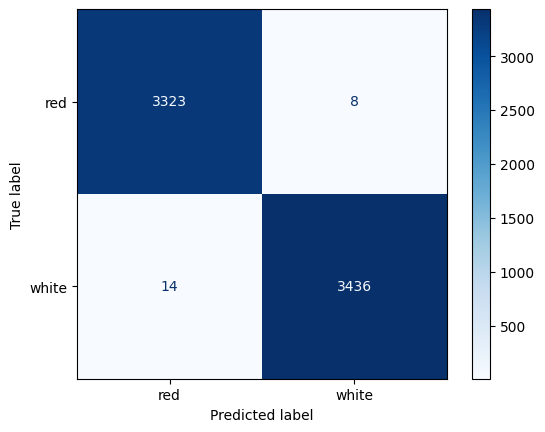

In [39]:
best_clf4 = clf4.best_estimator_
y_train_pred4 = cross_val_predict(best_clf4, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val4 = confusion_matrix(y_trainN, y_train_pred4)
ConfusionMatrixDisplay(confusion_matrix=cm_val4, display_labels=labels).plot(cmap=plt.cm.Blues)

Profundidad del árbol: 14
Número de hojas: 70


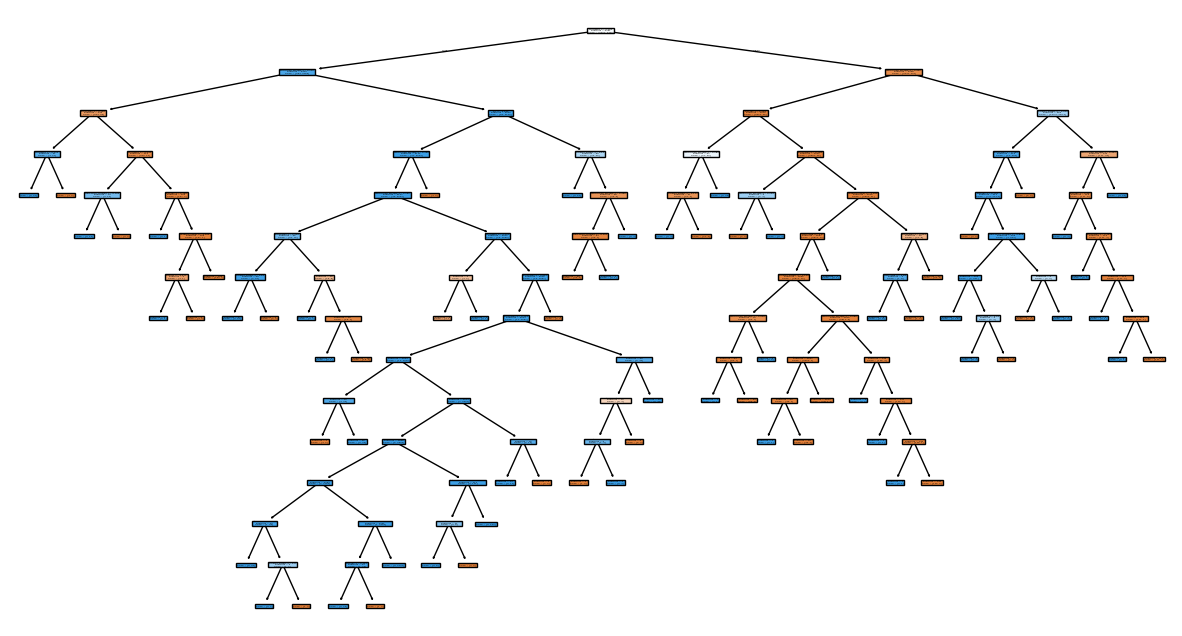

In [40]:
#Árbol de decisión
from sklearn.tree import DecisionTreeClassifier, plot_tree
model_tree = DecisionTreeClassifier(random_state=32)
model_tree.fit(X_trainN, y_trainN)
print(f'Profundidad del árbol: {model_tree.get_depth()}\nNúmero de hojas: {model_tree.get_n_leaves()}')
fig, ax = plt.subplots(figsize=(15,8))
plot = plot_tree(decision_tree= model_tree, feature_names=num_cols, filled=True, impurity=False, ax=ax)

In [41]:
#Árbol de decisión
model_5 = DecisionTreeClassifier(random_state=32)
param_grid = {
    'criterion': ['entropy', 'gini', 'log_loss'],
    'max_depth': [3,5,7,10,14],
    'max_leaf_nodes': [None, 5,10,20,30,50,60],
    'min_samples_split': [2,4,6]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf5 = GridSearchCV(estimator=model_5,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf5.fit(X_trainN, y_trainN)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=32)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 5, ...], 'min_samples_split': [2, 4, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",S

In [42]:
cv_results5 = pd.DataFrame(clf5.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results5.head(10))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_leaf_nodes,param_min_samples_split,params,split0_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
207,0.081084,0.023317,0.102028,0.037870,gini,14,60,2,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",0.994842,...,0.001964,1,0.994841,0.990412,0.991886,0.989675,0.994099,0.992182,0.002012,1
204,0.062542,0.018348,0.077270,0.023364,gini,14,50,2,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",0.995578,...,0.002523,2,0.995578,0.989675,0.991148,0.988936,0.994098,0.991887,0.002556,2
208,0.092936,0.057530,0.083516,0.012144,gini,14,60,4,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",0.990420,...,0.001324,11,0.990418,0.990412,0.991886,0.991887,0.994099,0.991740,0.001350,3
288,0.070535,0.029360,0.086341,0.022727,log_loss,10,50,2,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",0.992631,...,0.000859,3,0.992630,0.991887,0.992623,0.990411,0.991149,0.991740,0.000861,4
81,0.070202,0.036688,0.065529,0.020893,entropy,10,60,2,"{'criterion': 'entropy', 'max_depth': 10, 'max...",0.992631,...,0.000859,3,0.992630,0.991887,0.992623,0.990411,0.991149,0.991740,0.000861,4
78,0.058624,0.022890,0.077599,0.033269,entropy,10,50,2,"{'criterion': 'entropy', 'max_depth': 10, 'max...",0.992631,...,0.000859,3,0.992630,0.991887,0.992623,0.990411,0.991149,0.991740,0.000861,4
82,0.049504,0.018020,0.082987,0.007108,entropy,10,60,4,"{'criterion': 'entropy', 'max_depth': 10, 'max...",0.992631,...,0.000859,3,0.992630,0.991887,0.992623,0.990411,0.991149,0.991740,0.000861,4
79,0.047252,0.021855,0.120771,0.041241,entropy,10,50,4,"{'criterion': 'entropy', 'max_depth': 10, 'max...",0.992631,...,0.000859,3,0.992630,0.991887,0.992623,0.990411,0.991149,0.991740,0.000861,4
292,0.039531,0.006966,0.073544,0.012593,log_loss,10,60,4,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",0.992631,...,0.000859,3,0.992630,0.991887,0.992623,0.990411,0.991149,0.991740,0.000861,4
289,0.041027,0.004464,0.063967,0.013656,log_loss,10,50,4,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",0.992631,...,0.000859,3,0.992630,0.991887,0.992623,0.990411,0.991149,0.991740,0.000861,4


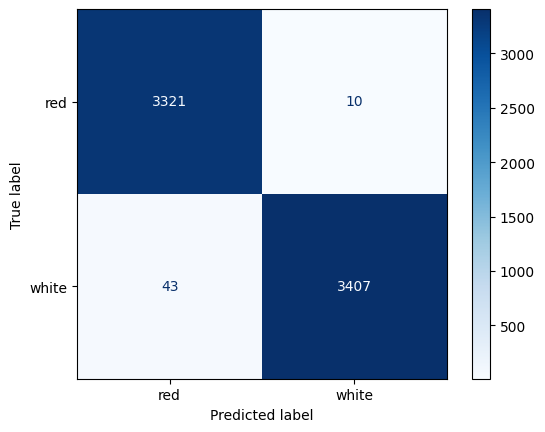

In [43]:
best_clf5 = clf5.best_estimator_
y_train_pred5 = cross_val_predict(best_clf5, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val5 = confusion_matrix(y_trainN, y_train_pred5)
ConfusionMatrixDisplay(confusion_matrix=cm_val5, display_labels=labels).plot(cmap=plt.cm.Blues)

In [44]:
#Extra Tree Classifier
from sklearn.ensemble import ExtraTreesClassifier
model_6 = ExtraTreesClassifier(random_state=32)
param_grid = {
    'criterion': ['entropy', 'gini', 'log_loss'],
    'max_depth': [3,5,7,10,14],
    'max_leaf_nodes': [None,5,10,20,30,50,60],
    'min_samples_split': [2,4,6],
    'n_estimators': [100,200,400,500]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf6 = GridSearchCV(estimator=model_6,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf6.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ExtraTreesCla...ndom_state=32)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 5, ...], 'min_samples_split': [2, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fol

In [45]:
cv_results6 = pd.DataFrame(clf6.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results6.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_leaf_nodes,param_min_samples_split,param_n_estimators,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
1176,0.570236,0.193496,0.123271,0.051564,log_loss,14,None,2,100,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.000554,1,0.998526,0.999262,0.997787,0.997787,0.998525,0.998377,0.000552,1
336,0.556083,0.144111,0.108337,0.018801,entropy,14,None,2,100,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.000554,1,0.998526,0.999262,0.997787,0.997787,0.998525,0.998377,0.000552,1
758,1.981026,0.192320,0.256989,0.054743,gini,14,None,2,400,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.000746,3,0.998526,0.999262,0.997787,0.997049,0.998525,0.998230,0.000752,3
1180,0.502161,0.073276,0.112752,0.016767,log_loss,14,None,4,100,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.000582,4,0.997789,0.997787,0.997787,0.997787,0.999262,0.998082,0.000590,4
340,0.685520,0.113975,0.145804,0.023772,entropy,14,None,4,100,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.000582,4,0.997789,0.997787,0.997787,0.997787,0.999262,0.998082,0.000590,4
338,2.259971,0.495833,0.254186,0.028041,entropy,14,None,2,400,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.000579,6,0.998526,0.998525,0.997787,0.997049,0.998525,0.998082,0.000590,6
1178,2.312712,0.783235,0.209294,0.041428,log_loss,14,None,2,400,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.000579,6,0.998526,0.998525,0.997787,0.997049,0.998525,0.998082,0.000590,6
759,2.874896,0.877801,0.329712,0.106945,gini,14,None,2,500,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.000749,6,0.998526,0.999262,0.997787,0.997049,0.997787,0.998082,0.000752,8
1177,1.160297,0.444483,0.163888,0.038310,log_loss,14,None,2,200,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.000751,9,0.998526,0.999262,0.997787,0.997049,0.997787,0.998082,0.000752,9
337,1.333016,0.287168,0.189000,0.038033,entropy,14,None,2,200,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.000751,9,0.998526,0.999262,0.997787,0.997049,0.997787,0.998082,0.000752,9


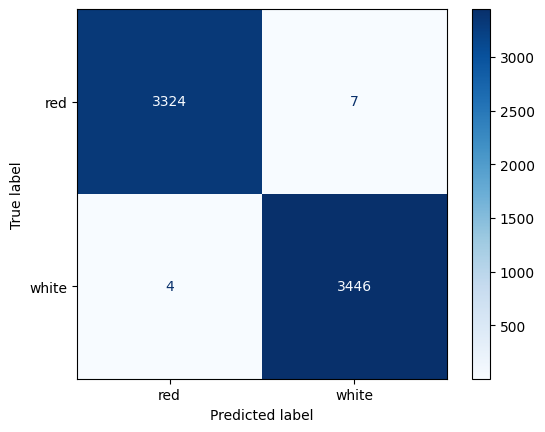

In [46]:
best_clf6 = clf6.best_estimator_
y_train_pred6 = cross_val_predict(best_clf6, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val6 = confusion_matrix(y_trainN, y_train_pred6)
ConfusionMatrixDisplay(confusion_matrix=cm_val6, display_labels=labels).plot(cmap=plt.cm.Blues)

In [47]:
#Random forest Classifier
from sklearn.ensemble import RandomForestClassifier
model_7 = RandomForestClassifier(random_state=32)
param_grid = {
    'criterion': ['entropy', 'gini', 'log_loss'],
    'max_depth': [3,5,7,10,14],
    'max_leaf_nodes': [None,5,10,20,30,50,60],
    'min_samples_split': [2,4,6],
    'n_estimators': [100,200,400,500]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf7 = GridSearchCV(estimator=model_7,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf7.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=32)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['entropy', 'gini', ...], 'max_depth': [3, 5, ...], 'max_leaf_nodes': [None, 5, ...], 'min_samples_split': [2, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fol

In [48]:
cv_results7 = pd.DataFrame(clf7.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results7.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_max_leaf_nodes,param_min_samples_split,param_n_estimators,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
1094,5.638338,1.872140,0.261319,0.080564,log_loss,10,None,2,400,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",...,0.000450,1,0.998526,0.998525,0.999262,0.997787,0.998525,0.998525,0.000467,1
254,5.541258,1.941697,0.267382,0.125998,entropy,10,None,2,400,"{'criterion': 'entropy', 'max_depth': 10, 'max...",...,0.000450,1,0.998526,0.998525,0.999262,0.997787,0.998525,0.998525,0.000467,1
255,7.387828,2.367103,0.293684,0.099019,entropy,10,None,2,500,"{'criterion': 'entropy', 'max_depth': 10, 'max...",...,0.000450,1,0.998526,0.998525,0.999262,0.997787,0.998525,0.998525,0.000467,1
339,6.569989,1.735385,0.239344,0.029718,entropy,14,None,2,500,"{'criterion': 'entropy', 'max_depth': 14, 'max...",...,0.000450,1,0.998526,0.998525,0.999262,0.997787,0.998525,0.998525,0.000467,1
1179,7.799041,3.213544,0.289354,0.074367,log_loss,14,None,2,500,"{'criterion': 'log_loss', 'max_depth': 14, 'ma...",...,0.000450,1,0.998526,0.998525,0.999262,0.997787,0.998525,0.998525,0.000467,1
1095,5.632021,0.609388,0.282806,0.021864,log_loss,10,None,2,500,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",...,0.000450,1,0.998526,0.998525,0.999262,0.997787,0.998525,0.998525,0.000467,1
762,6.867991,1.899795,0.289305,0.064270,gini,14,None,4,400,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.000451,1,0.999263,0.998525,0.998525,0.997787,0.998525,0.998525,0.000467,7
763,7.366986,1.687305,0.327354,0.059800,gini,14,None,4,500,"{'criterion': 'gini', 'max_depth': 14, 'max_le...",...,0.000451,1,0.999263,0.998525,0.998525,0.997787,0.998525,0.998525,0.000467,7
1099,7.242114,1.985667,0.321640,0.078270,log_loss,10,None,4,500,"{'criterion': 'log_loss', 'max_depth': 10, 'ma...",...,0.000542,25,0.997789,0.998525,0.999262,0.997787,0.998525,0.998377,0.000552,9
259,7.234357,2.709880,0.304254,0.102867,entropy,10,None,4,500,"{'criterion': 'entropy', 'max_depth': 10, 'max...",...,0.000542,25,0.997789,0.998525,0.999262,0.997787,0.998525,0.998377,0.000552,9


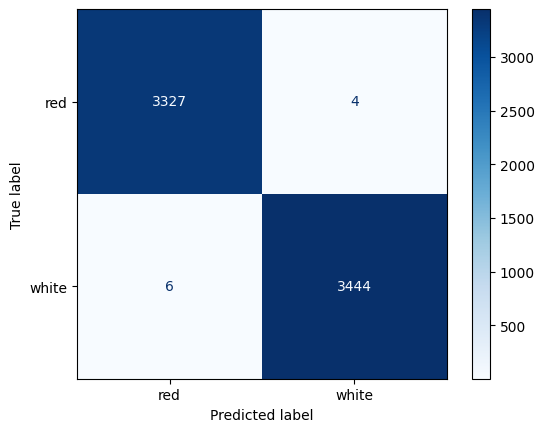

In [49]:
best_clf7 = clf7.best_estimator_
y_train_pred7 = cross_val_predict(best_clf7, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val7 = confusion_matrix(y_trainN, y_train_pred7)
ConfusionMatrixDisplay(confusion_matrix=cm_val7, display_labels=labels).plot(cmap=plt.cm.Blues)

In [50]:
#Adaptive boosting Classifier
from sklearn.ensemble import AdaBoostClassifier
model_8 = AdaBoostClassifier(random_state=32)
param_grid = {
    'learning_rate': [0.01, 0.1, 1,10,100],
    'n_estimators': [100,200,400,500]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf8 = GridSearchCV(estimator=model_8,
                    param_grid=param_grid,
                    cv=cv,
                    scoring=scoring,
                    refit='f1_macro',
                    n_jobs=-1)
clf8.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=32)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the 

In [51]:
cv_results8 = pd.DataFrame(clf8.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results8.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_learning_rate,param_n_estimators,params,split0_test_accuracy,split1_test_accuracy,split2_test_accuracy,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
10,8.711739,1.832360,0.279084,0.076861,1.00,400,"{'learning_rate': 1, 'n_estimators': 400}",0.997789,0.995575,0.994100,...,0.001492,1,0.997789,0.995574,0.994099,0.997787,0.997787,0.996607,0.001519,1
11,11.558786,1.996439,0.282534,0.068089,1.00,500,"{'learning_rate': 1, 'n_estimators': 500}",0.996315,0.995575,0.994100,...,0.001547,2,0.996315,0.995574,0.994099,0.998525,0.997787,0.996460,0.001575,2
9,5.163445,1.281965,0.229644,0.017129,1.00,200,"{'learning_rate': 1, 'n_estimators': 200}",0.996315,0.995575,0.990413,...,0.002592,3,0.996314,0.995574,0.990411,0.997049,0.997787,0.995427,0.002614,3
8,1.853468,0.161775,0.126157,0.025777,1.00,100,"{'learning_rate': 1, 'n_estimators': 100}",0.994842,0.993363,0.987463,...,0.002519,4,0.994840,0.993361,0.987460,0.992623,0.993360,0.992329,0.002539,4
7,8.957548,0.984697,0.360750,0.108067,0.10,500,"{'learning_rate': 0.1, 'n_estimators': 500}",0.991157,0.991888,0.986726,...,0.001780,5,0.991154,0.991886,0.986722,0.990410,0.989672,0.989969,0.001783,5
6,11.634582,2.041340,0.363744,0.074948,0.10,400,"{'learning_rate': 0.1, 'n_estimators': 400}",0.990420,0.991888,0.985988,...,0.001948,6,0.990417,0.991886,0.985984,0.989672,0.989672,0.989526,0.001947,6
5,3.530339,0.379400,0.186111,0.032405,0.10,200,"{'learning_rate': 0.1, 'n_estimators': 200}",0.986735,0.991150,0.982301,...,0.002933,7,0.986732,0.991148,0.982296,0.986722,0.988934,0.987166,0.002935,7
4,2.323316,0.431348,0.161817,0.012719,0.10,100,"{'learning_rate': 0.1, 'n_estimators': 100}",0.985262,0.987463,0.980826,...,0.002201,8,0.985258,0.987459,0.980821,0.983035,0.984506,0.984216,0.002218,8
3,13.294849,2.467131,0.449871,0.120297,0.01,500,"{'learning_rate': 0.01, 'n_estimators': 500}",0.986735,0.980826,0.974926,...,0.003857,9,0.986732,0.980821,0.974918,0.978606,0.979340,0.980083,0.003851,9
2,9.003526,1.766088,0.346827,0.063921,0.01,400,"{'learning_rate': 0.01, 'n_estimators': 400}",0.981577,0.980826,0.971239,...,0.003729,10,0.981569,0.980821,0.971231,0.977869,0.980077,0.978313,0.003751,10


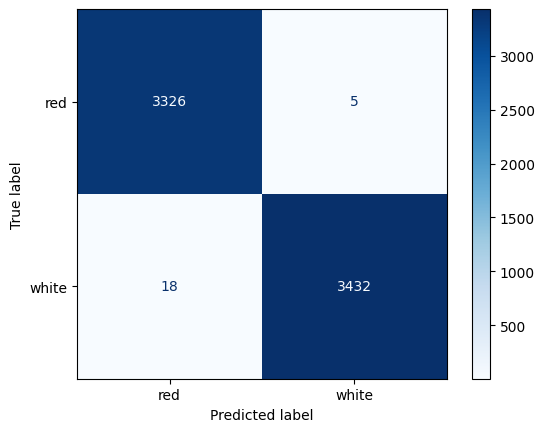

In [52]:
best_clf8 = clf8.best_estimator_
y_train_pred8 = cross_val_predict(best_clf8, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val8 = confusion_matrix(y_trainN, y_train_pred8)
ConfusionMatrixDisplay(confusion_matrix=cm_val8, display_labels=labels).plot(cmap=plt.cm.Blues)

In [53]:
#GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
model_9 = GradientBoostingClassifier(random_state=32)
param_grid = {
    'criterion': ['friedman_mse', 'squared_error'],
    'max_depth': [5,7,9,12],
    'max_leaf_nodes': [10,40,None],
    'min_samples_split': [2,3],
    'n_estimators': [100,200,300,400]
    }
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf9 = RandomizedSearchCV(estimator= model_9, param_distributions=param_grid, cv=cv, scoring=scoring,
                          refit='f1_macro',
                          n_jobs=-1, n_iter=96)
clf9.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=32)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['friedman_mse', 'squared_error'], 'max_depth': [5, 7, ...], 'max_leaf_nodes': [10, 40, ...], 'min_samples_split': [2, 3], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",96
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the 

In [54]:
cv_results9 = pd.DataFrame(clf9.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results9.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_estimators,param_min_samples_split,param_max_leaf_nodes,param_max_depth,param_criterion,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
67,15.707347,1.985506,0.105256,0.014184,400,2,40,12,squared_error,"{'n_estimators': 400, 'min_samples_split': 2, ...",...,0.000726,1,0.998526,0.997050,0.999262,0.997787,0.998525,0.998230,0.000752,1
69,16.847991,3.514723,0.127202,0.022883,400,3,40,5,squared_error,"{'n_estimators': 400, 'min_samples_split': 3, ...",...,0.000726,1,0.998526,0.997050,0.999262,0.997787,0.998525,0.998230,0.000752,1
73,17.054964,3.649301,0.133674,0.021037,400,3,40,12,squared_error,"{'n_estimators': 400, 'min_samples_split': 3, ...",...,0.000726,1,0.998526,0.997050,0.999262,0.997787,0.998525,0.998230,0.000752,1
87,20.265072,6.126682,0.102525,0.011802,400,2,40,12,friedman_mse,"{'n_estimators': 400, 'min_samples_split': 2, ...",...,0.000726,1,0.998526,0.997050,0.999262,0.997787,0.998525,0.998230,0.000752,1
85,14.097376,3.429347,0.096624,0.025239,400,3,None,5,friedman_mse,"{'n_estimators': 400, 'min_samples_split': 3, ...",...,0.000970,5,0.998526,0.996312,0.999262,0.997787,0.998525,0.998082,0.001001,5
62,13.892173,3.018325,0.091618,0.032063,400,3,None,5,squared_error,"{'n_estimators': 400, 'min_samples_split': 3, ...",...,0.000970,5,0.998526,0.996312,0.999262,0.997787,0.998525,0.998082,0.001001,5
25,16.798894,1.132075,0.131947,0.015664,300,3,40,12,friedman_mse,"{'n_estimators': 300, 'min_samples_split': 3, ...",...,0.000564,5,0.998526,0.997050,0.998525,0.997787,0.998525,0.998082,0.000590,7
77,16.133997,3.898131,0.106254,0.006106,400,2,40,7,friedman_mse,"{'n_estimators': 400, 'min_samples_split': 2, ...",...,0.000564,5,0.998526,0.997050,0.998525,0.997787,0.998525,0.998082,0.000590,7
36,17.929521,1.993088,0.141111,0.034485,400,3,40,12,friedman_mse,"{'n_estimators': 400, 'min_samples_split': 3, ...",...,0.000527,9,0.997789,0.997050,0.998525,0.997787,0.998525,0.997935,0.000552,9
3,13.892113,2.652768,0.132750,0.050872,300,3,40,5,friedman_mse,"{'n_estimators': 300, 'min_samples_split': 3, ...",...,0.000527,9,0.997789,0.997050,0.998525,0.997787,0.998525,0.997935,0.000552,9


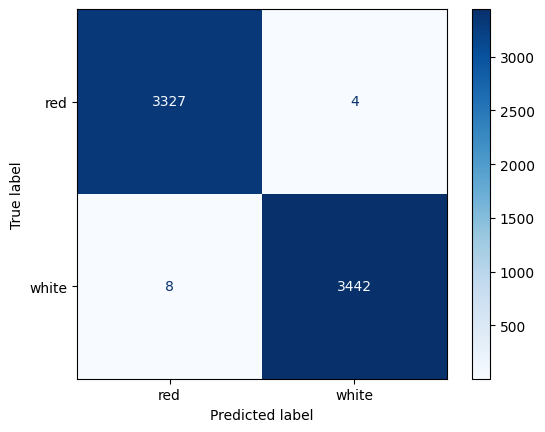

In [55]:
best_clf9 = clf9.best_estimator_
y_train_pred9 = cross_val_predict(best_clf9, X_trainN, y_trainN, cv=cv, n_jobs=-1)
cm_val9 = confusion_matrix(y_trainN, y_train_pred9)
ConfusionMatrixDisplay(confusion_matrix=cm_val9, display_labels=labels).plot(cmap=plt.cm.Blues)

In [56]:
#Red Neuronal Perceptrón Multicapa
from sklearn.neural_network import MLPClassifier
model_10 = MLPClassifier(random_state=32)
param_grid = {
    'hidden_layer_sizes': [(10,),(20,10,5),(20,10),(20,),(50,40,30,20,10)],
    'activation': ['relu','tanh','logistic'],
    'solver': ['adam','lbfgs','sgd'],
    'learning_rate_init': [0.01, 0.1, 1, 10, 100],
    'max_iter': [50,70,100,200]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=32)
clf10 = RandomizedSearchCV(estimator= model_10, param_distributions=param_grid, cv=cv, scoring=scoring,
                           refit='f1_macro',
                          n_jobs=-1, n_iter=180)
clf10.fit(X_trainN, y_trainN)

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
1 fits failed out of a total of 900.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\neura

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MLPClassifier(random_state=32)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'activation': ['relu', 'tanh', ...], 'hidden_layer_sizes': [(10,), (20, ...), ...], 'learning_rate_init': [0.01, 0.1, ...], 'max_iter': [50, 70, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",180
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'precision_macro': 'precision_macro', 'recall_macro': 'recall_macro'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffl

In [57]:
cv_results10 = pd.DataFrame(clf10.cv_results_).sort_values("mean_test_f1_macro", ascending=False)
display(cv_results10.head(10)) 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_solver,param_max_iter,param_learning_rate_init,param_hidden_layer_sizes,param_activation,params,...,std_test_recall_macro,rank_test_recall_macro,split0_test_f1_macro,split1_test_f1_macro,split2_test_f1_macro,split3_test_f1_macro,split4_test_f1_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
39,1.012473,0.257746,0.067772,0.019682,lbfgs,200,0.01,"(10,)",tanh,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.001123,1,0.995577,0.993362,0.996311,0.996312,0.996312,0.995575,0.001143,1
103,3.503811,0.854809,0.085946,0.021855,lbfgs,200,10.00,"(20, 10)",tanh,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.001680,2,0.997051,0.995574,0.997049,0.992625,0.994099,0.995280,0.001721,2
61,1.151351,0.257086,0.084130,0.017942,lbfgs,100,0.10,"(20,)",tanh,"{'solver': 'lbfgs', 'max_iter': 100, 'learning...",...,0.001003,3,0.994840,0.995574,0.997049,0.994098,0.994836,0.995279,0.001000,3
126,1.559366,0.257289,0.078194,0.021045,lbfgs,200,0.10,"(10,)",logistic,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.001083,4,0.997051,0.994099,0.995574,0.994099,0.994836,0.995132,0.001105,4
29,1.735631,0.478929,0.086105,0.015525,lbfgs,100,1.00,"(20, 10)",tanh,"{'solver': 'lbfgs', 'max_iter': 100, 'learning...",...,0.001155,5,0.995577,0.995574,0.995574,0.992624,0.995574,0.994984,0.001180,5
93,1.449634,0.300153,0.077716,0.006649,lbfgs,200,0.01,"(20,)",relu,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.001865,6,0.996314,0.991886,0.996311,0.995574,0.992624,0.994542,0.001901,6
19,1.390272,0.354165,0.085858,0.039702,lbfgs,200,0.10,"(20,)",relu,"{'solver': 'lbfgs', 'max_iter': 200, 'learning...",...,0.001865,6,0.996314,0.991886,0.996311,0.995574,0.992624,0.994542,0.001901,6
52,0.884412,0.137701,0.086416,0.006990,lbfgs,70,0.10,"(20,)",tanh,"{'solver': 'lbfgs', 'max_iter': 70, 'learning_...",...,0.001372,8,0.994839,0.995574,0.996312,0.992623,0.993361,0.994542,0.001368,8
105,0.663734,0.140441,0.081560,0.016604,lbfgs,50,10.00,"(20,)",tanh,"{'solver': 'lbfgs', 'max_iter': 50, 'learning_...",...,0.001636,9,0.996314,0.994836,0.996311,0.992623,0.992623,0.994541,0.001657,9
57,3.809768,1.070712,0.098804,0.023678,adam,200,0.01,"(20, 10)",relu,"{'solver': 'adam', 'max_iter': 200, 'learning_...",...,0.001655,10,0.995576,0.994098,0.991147,0.995574,0.994835,0.994246,0.001644,10


## Validación cruzada en un mismo for

In [58]:
hola = [[],[]]
hola[0].append(4)
hola[1].append(6)
print(hola)
print(hola[0])

[[4], [6]]
[4]


In [73]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score


strtfdKFold = StratifiedKFold(n_splits=10)
folds = list(strtfdKFold.split(X_trainN, y_trainN))

models = {
    'Naive Bayes': clf1.best_estimator_,
    'Regresión Logística': clf2.best_estimator_,
    'KNN': clf3.best_estimator_,
    'Maquina de Soporte Vectorial': clf4.best_estimator_,
    'Árbol de Decisión': clf5.best_estimator_,
    'Extra Trees': clf6.best_estimator_,
    'Random Forest': clf7.best_estimator_,
    'Adaptative Boosting': clf8.best_estimator_,
    'Gradient Boosting': clf9.best_estimator_,
    'Multi Layer Perceptron': clf10.best_estimator_
}

results = {name: {'accuracy': [], 'f1': [], 'recall': [], 'precision': [],
                  'y_test': [], 'y_pred': []}         
           for name in models}

for model_name, model in models.items():
    for train_index, test_index in folds:
        X_train_cv, X_test_cv = X_trainN.iloc[train_index], X_trainN.iloc[test_index]
        y_train_cv, y_test_cv = y_trainN.iloc[train_index], y_trainN.iloc[test_index]
        
        model.fit(X_train_cv, y_train_cv)
        pred = model.predict(X_test_cv)
        
        results[model_name]['y_test'].extend(y_test_cv['type'].tolist()) 
        results[model_name]['y_pred'].extend(pred)        
        results[model_name]['accuracy'].append(accuracy_score(y_test_cv, pred))
        results[model_name]['f1'].append(f1_score(y_test_cv, pred, average='macro'))
        results[model_name]['recall'].append(recall_score(y_test_cv, pred, average='macro'))
        results[model_name]['precision'].append(precision_score(y_test_cv, pred, average='macro'))

c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\migue\anaconda3\envs\IngDatos\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array w

In [86]:
for model in results:
    print(f'f1 de {model}: {np.mean(results[model]['f1'])*100}')

f1 de Naive Bayes: 97.50667784138734
f1 de Regresión Logística: 99.35080410735382
f1 de KNN: 99.32149852178505
f1 de Maquina de Soporte Vectorial: 99.7344345752173
f1 de Árbol de Decisión: 99.30673688816054
f1 de Extra Trees: 99.80819831536894
f1 de Random Forest: 99.83773324620353
f1 de Adaptative Boosting: 99.61650602725783
f1 de Gradient Boosting: 99.85248337425202
f1 de Multi Layer Perceptron: 99.60165350105103


In [77]:
for model in results:
    print(f'accuracy de {model}: {np.mean(results[model]['accuracy'])*100}')

accuracy de Naive Bayes: 97.5077004618105
accuracy de Regresión Logística: 99.35105417041372
accuracy de KNN: 99.32162081144838
accuracy de Maquina de Soporte Vectorial: 99.7345132743363
accuracy de Árbol de Decisión: 99.30684982687538
accuracy de Extra Trees: 99.80825958702064
accuracy de Random Forest: 99.83777983413053
accuracy de Adaptative Boosting: 99.61658434014971
accuracy de Gradient Boosting: 99.85252909666741
accuracy de Multi Layer Perceptron: 99.60176991150445


In [78]:
for model in results:
    print(f'precision de {model}: {np.mean(results[model]['precision'])*100}')

precision de Naive Bayes: 97.51553084746284
precision de Regresión Logística: 99.35603108407942
precision de KNN: 99.31898556973424
precision de Maquina de Soporte Vectorial: 99.73487141161264
precision de Árbol de Decisión: 99.30524014736892
precision de Extra Trees: 99.8087623198677
precision de Random Forest: 99.83727994100128
precision de Adaptative Boosting: 99.61459194657382
precision de Gradient Boosting: 99.85276636867273
precision de Multi Layer Perceptron: 99.60205071359475


In [79]:
for model in results:
    print(f'recall de {model}: {np.mean(results[model]['recall'])*100}')

recall de Naive Bayes: 97.50464797002158
recall de Regresión Logística: 99.34774047674335
recall de KNN: 99.32815567454985
recall de Maquina de Soporte Vectorial: 99.734952343648
recall de Árbol de Decisión: 99.3141402271837
recall de Extra Trees: 99.80793837315576
recall de Random Forest: 99.83849066457763
recall de Adaptative Boosting: 99.6210993602298
recall de Gradient Boosting: 99.85246115680899
recall de Multi Layer Perceptron: 99.60190625408018


Matriz de Naive Bayes


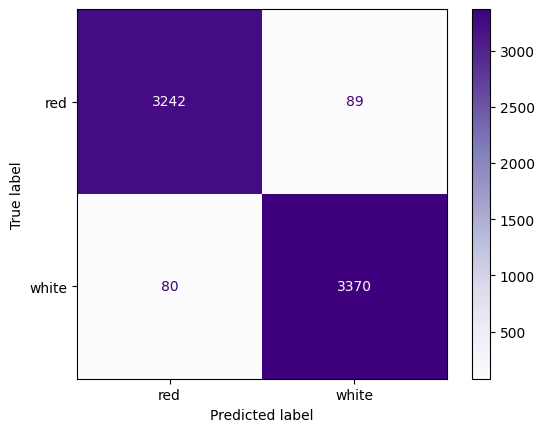

Matriz de Regresión Logística


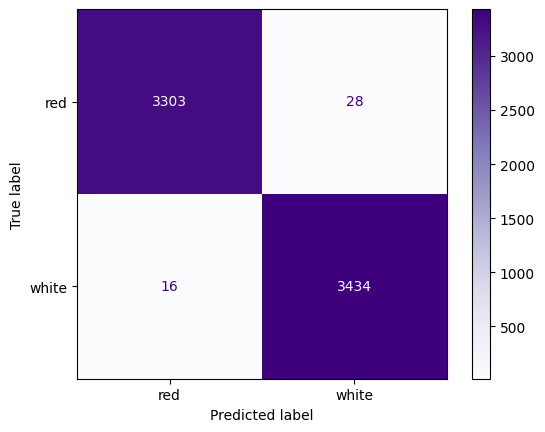

Matriz de KNN


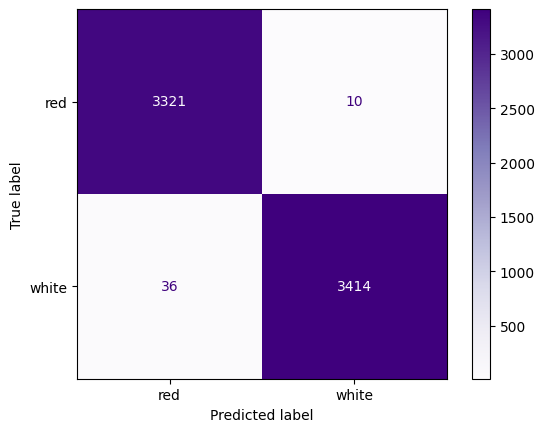

Matriz de Maquina de Soporte Vectorial


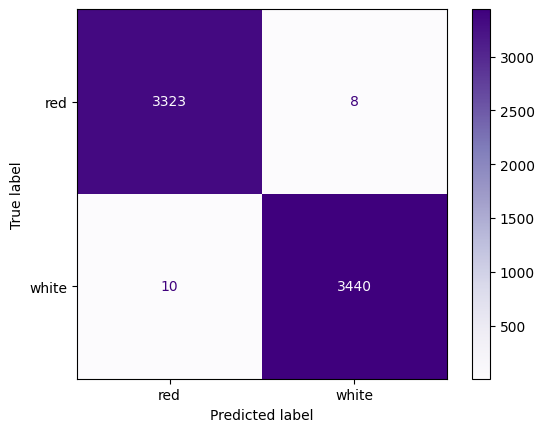

Matriz de Árbol de Decisión


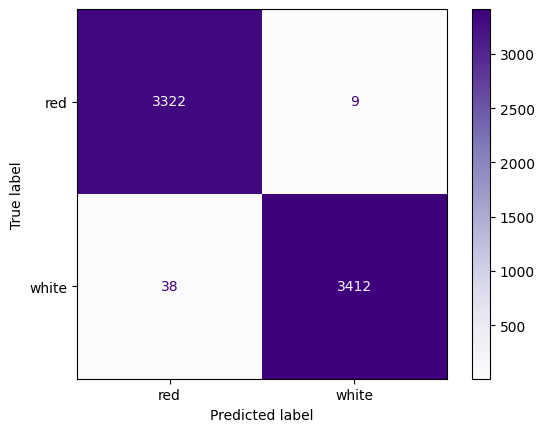

Matriz de Extra Trees


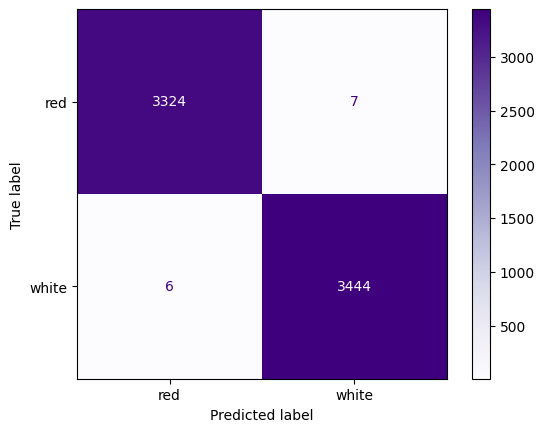

Matriz de Random Forest


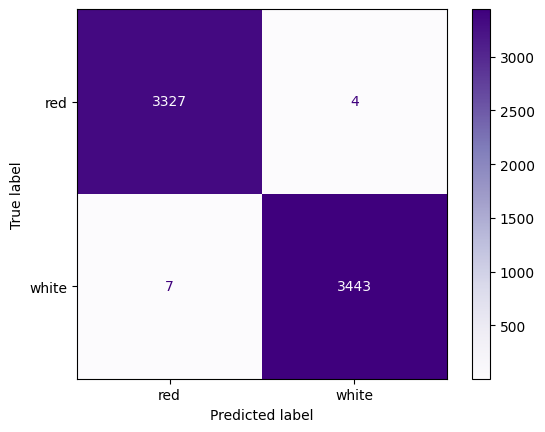

Matriz de Adaptative Boosting


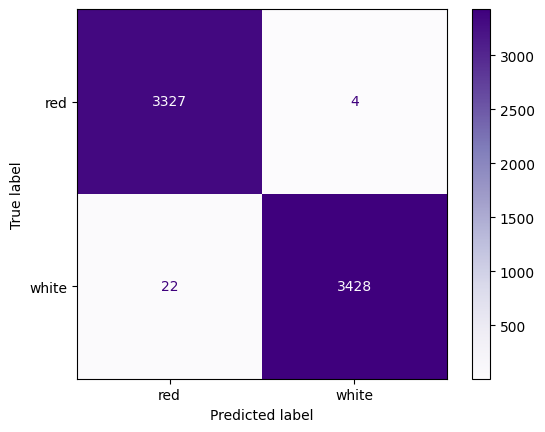

Matriz de Gradient Boosting


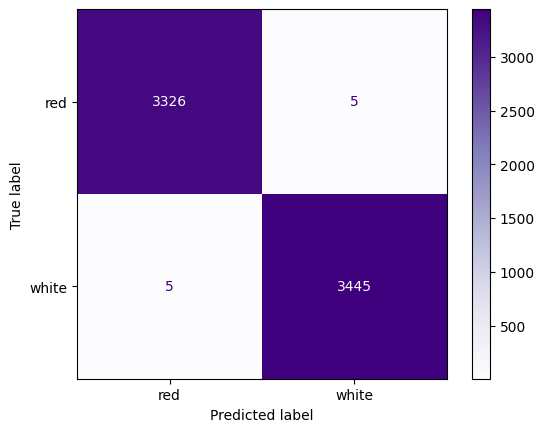

Matriz de Multi Layer Perceptron


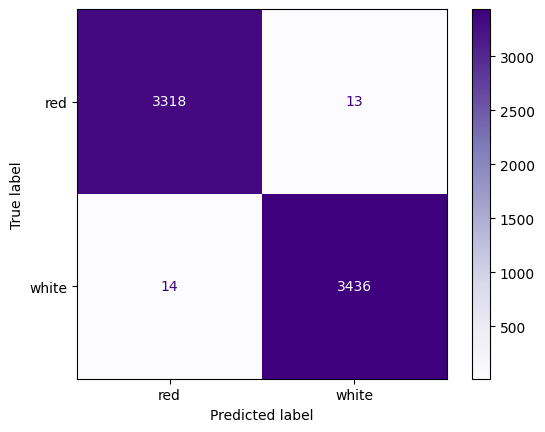

In [83]:
for model in results:
    print(f'Matriz de {model}')
    cm_val = confusion_matrix(results[model]['y_test'], results[model]['y_pred'])
    ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=labels).plot(cmap=plt.cm.Purples)
    plt.show()

## Mejores modelos seleccionados
Nos quedaremos con los modelos que mejor se desempeñaron, en nuestro caso:
- Extra trees
- Random Forest
- Gradient Boosting

## Selección de rasgos
Probaremos diferentes metodos de selección de rasgos con nuestro dataset, para determinar cuales rasgos entregan más eficiencia computacional y desempeño.

In [100]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import (
    SelectKBest, f_classif, chi2, mutual_info_classif,
    RFECV, SelectFromModel, SequentialFeatureSelector
)
from sklearn import metrics
import warnings

warnings.filterwarnings("ignore")

feature_names = X_trainN.columns

# Subconjunto interno para decidir hiperparámetros de selección, como el número k de rasgos.
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_trainN, y_trainN, test_size=0.25, stratify=y_trainN, random_state=32
)

def modelo_evaluacion():
    return GradientBoostingClassifier(n_estimators=20, random_state=32)

def calcular_metricas(y_real, y_pred):
    return {
        "Accuracy": metrics.accuracy_score(y_real['type'].tolist(), y_pred),
        "F1 macro": metrics.f1_score(y_real['type'].tolist(), y_pred, average="macro")
    }

def evaluar_features_en_validacion(features):
    model = modelo_evaluacion()
    model.fit(X_subtrain[features], y_subtrain)
    pred_val = model.predict(X_val[features])
    return calcular_metricas(y_val, pred_val)

def evaluar_features_en_test(features):
    model = modelo_evaluacion()
    model.fit(X_trainN[features], y_trainN)
    pred_test = model.predict(X_testN[features])
    return calcular_metricas(y_testN, pred_test)

def seleccionar_mejor_k_desde_ranking(nombre, ranking_features):
    filas = []
    for k in range(1, len(ranking_features) + 1):
        feats = list(ranking_features[:k])
        met = evaluar_features_en_validacion(feats)
        filas.append({
            "Método": nombre,
            "k": k,
            "Rasgos": feats,
            "Accuracy validación": met["Accuracy"],
            "F1 macro validación": met["F1 macro"]
        })
    df_k = pd.DataFrame(filas)
    mejor = df_k.sort_values(
        by=["F1 macro validación", "Accuracy validación"],
        ascending=False
    ).iloc[0]
    return list(mejor["Rasgos"]), df_k

print("Entrenamiento:", X_trainN.shape)
print("Validación interna:", X_val.shape)
print("Prueba final:", X_testN.shape)


Entrenamiento: (6781, 12)
Validación interna: (1696, 12)
Prueba final: (2907, 12)


In [101]:
#Modelo 1: Todos los rasgos
feature_sets_previos = {}
curvas_validacion_previas = {}

feature_sets_previos["Todos los rasgos"] = list(feature_names)

In [102]:
#Modelo 2: selectKBest con ANOVA
anova_selector = SelectKBest(score_func=f_classif, k="all")
anova_selector.fit(X_subtrain, y_subtrain)
anova_ranking = pd.Series(anova_selector.scores_, index=feature_names).sort_values(ascending=False).index
feature_sets_previos["SelectKBest ANOVA"] , curvas_validacion_previas["SelectKBest ANOVA"] = seleccionar_mejor_k_desde_ranking("SelectKBest ANOVA", anova_ranking)

In [105]:
#Modelo 3: selectKBest con chi2
chi2_selector = SelectKBest(score_func=chi2, k="all")
chi2_selector.fit(X_subtrain, y_subtrain)
chi2_ranking = pd.Series(chi2_selector.scores_, index=feature_names).sort_values(ascending=False).index
feature_sets_previos["SelectKBest Chi2"], curvas_validacion_previas["SelectKBest Chi2"] = seleccionar_mejor_k_desde_ranking("SelectKBest Chi2", chi2_ranking)

In [107]:
#Modelo 4: SelectKBest con informacion mutua
mi_scores = mutual_info_classif(X_subtrain, y_subtrain, random_state=32)
mi_ranking = pd.Series(mi_scores, index=feature_names).sort_values(ascending=False).index
feature_sets_previos["Información mutua"], curvas_validacion_previas["Información mutua"] = seleccionar_mejor_k_desde_ranking("Información mutua", mi_ranking)

In [108]:
#Modelo 5: Forward Selection
filas_sfs = []
for k in range(1, len(feature_names)):
    sfs = SequentialFeatureSelector(
        LogisticRegression(max_iter=2000, class_weight="balanced"),
        n_features_to_select=k,
        direction="forward",
        scoring="f1",
        cv=5,
        n_jobs=-1
    )

    pipe_sfs = Pipeline([
        ("scale", StandardScaler()),
        ("sfs", sfs)
    ])

    pipe_sfs.fit(X_subtrain, y_subtrain)
    selected = list(feature_names[pipe_sfs.named_steps["sfs"].get_support()])
    met = evaluar_features_en_validacion(selected)

    filas_sfs.append({
        "Método": "Forward Selection",
        "k": k,
        "Rasgos": selected,
        "Accuracy validación": met["Accuracy"],
        "F1 macro validación": met["F1 macro"]
    })

curvas_validacion_previas["Forward Selection"] = pd.DataFrame(filas_sfs)
mejor_sfs = curvas_validacion_previas["Forward Selection"].sort_values(
    by=["F1 macro validación", "Accuracy validación"],
    ascending=False
).iloc[0]
feature_sets_previos["Forward Selection"] = list(mejor_sfs["Rasgos"])

In [111]:
#Modelo 6: RFECV
rfecv = RFECV(
    estimator=LogisticRegression(max_iter=2000, class_weight="balanced"),
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=32),
    scoring="f1_macro",
    min_features_to_select=1,
    n_jobs=-1
)

pipe_rfecv = Pipeline([
    ("scale", StandardScaler()),
    ("rfecv", rfecv)
])

pipe_rfecv.fit(X_subtrain, y_subtrain)
feature_sets_previos["RFECV"] = list(feature_names[pipe_rfecv.named_steps["rfecv"].support_])

In [113]:
#Modelo 7: Embebida con L1
l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=0.1,
    max_iter=2000,
    class_weight="balanced",
    random_state=32
)

pipe_l1 = Pipeline([
    ("scale", StandardScaler()),
    ("select", SelectFromModel(l1_model))
])

pipe_l1.fit(X_subtrain, y_subtrain)
mask_l1 = pipe_l1.named_steps["select"].get_support()

if mask_l1.sum() == 0:
    l1_model = LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=1.0,
        max_iter=2000,
        class_weight="balanced",
        random_state=32
    )
    pipe_l1 = Pipeline([
        ("scale", StandardScaler()),
        ("select", SelectFromModel(l1_model))
    ])
    pipe_l1.fit(X_subtrain, y_subtrain)
    mask_l1 = pipe_l1.named_steps["select"].get_support()

feature_sets_previos["L1 embebido"] = list(feature_names[mask_l1])

In [114]:
#Modelo 8: Importancia con Gradient Boosting
gb_selector = GradientBoostingClassifier(n_estimators=20, random_state=32)
gb_selector.fit(X_subtrain, y_subtrain)
gb_ranking = pd.Series(gb_selector.feature_importances_, index=feature_names).sort_values(ascending=False).index
feature_sets_previos["Importancia Gradient Boosting"], curvas_validacion_previas["Importancia Gradient Boosting"] = seleccionar_mejor_k_desde_ranking("Importancia Gradient Boosting", gb_ranking)

print(feature_sets_previos)

{'Todos los rasgos': ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality'], 'SelectKBest ANOVA': ['total sulfur dioxide', 'volatile acidity', 'free sulfur dioxide', 'sulphates', 'chlorides', 'density', 'fixed acidity'], 'SelectKBest Chi2': ['total sulfur dioxide', 'free sulfur dioxide', 'volatile acidity', 'residual sugar', 'sulphates', 'chlorides', 'fixed acidity', 'density'], 'Información mutua': ['chlorides', 'total sulfur dioxide', 'volatile acidity', 'residual sugar', 'density', 'free sulfur dioxide', 'sulphates', 'fixed acidity'], 'Forward Selection': ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates'], 'RFECV': ['fixed acidity', 'volatile acidity', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'su

In [115]:
resultados_previos = []

for metodo, feats in feature_sets_previos.items():
    met = evaluar_features_en_test(feats)
    resultados_previos.append({
        "Método": metodo,
        "Número de rasgos": len(feats),
        "Rasgos seleccionados": feats,
        "Accuracy prueba": met["Accuracy"],
        "F1 macro prueba": met["F1 macro"]
    })

benchmark_prev_df = (
    pd.DataFrame(resultados_previos).sort_values(by=["F1 macro prueba", "Accuracy prueba"], ascending=False).reset_index(drop=True))

benchmark_prev_df


,Método,Número de rasgos,Rasgos seleccionados,Accuracy prueba,F1 macro prueba
0,L1 embebido,10,"[volatile acidity, citric acid, residual sugar...",0.984520,0.984498
1,Importancia Gradient Boosting,6,"[chlorides, total sulfur dioxide, volatile aci...",0.984176,0.984153
2,Todos los rasgos,12,"[fixed acidity, volatile acidity, citric acid,...",0.983144,0.983120
3,Forward Selection,10,"[fixed acidity, volatile acidity, citric acid,...",0.983144,0.983120
4,RFECV,11,"[fixed acidity, volatile acidity, residual sug...",0.983144,0.983120
5,SelectKBest ANOVA,7,"[total sulfur dioxide, volatile acidity, free ...",0.982456,0.982433
6,SelectKBest Chi2,8,"[total sulfur dioxide, free sulfur dioxide, vo...",0.981424,0.981398
7,Información mutua,8,"[chlorides, total sulfur dioxide, volatile aci...",0.981424,0.981398


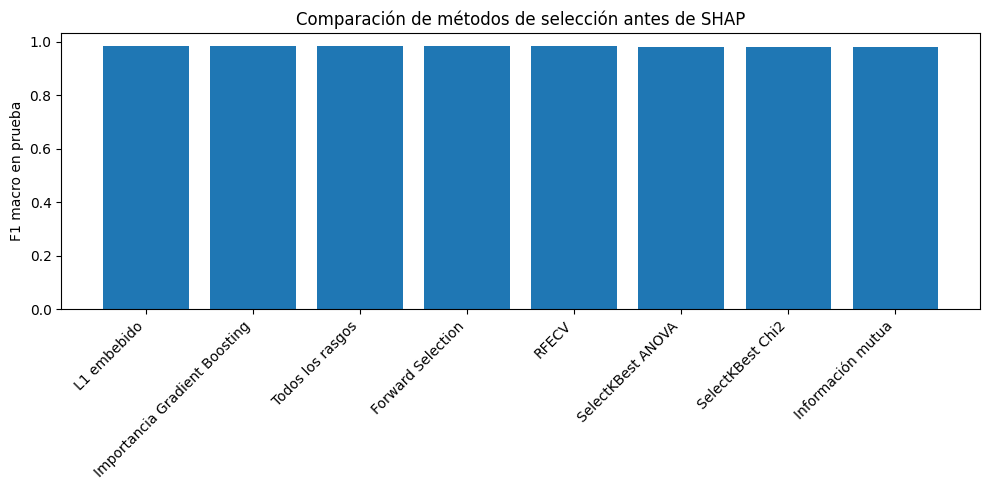

In [124]:
plt.figure(figsize=(10, 5))
plt.bar(benchmark_prev_df["Método"], benchmark_prev_df["F1 macro prueba"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 macro en prueba")
plt.title("Comparación de métodos de selección antes de SHAP")
plt.tight_layout()
plt.show()

In [120]:
from collections import Counter

contador_rasgos = Counter()

for metodo, feats in feature_sets_previos.items():
    if metodo != "Todos los rasgos":
        contador_rasgos.update(feats)

estabilidad_rasgos = (
    pd.DataFrame(contador_rasgos.items(), columns=["Rasgo", "Número de métodos que lo seleccionan"])
      .sort_values(by="Número de métodos que lo seleccionan", ascending=False)
      .reset_index(drop=True)
)

estabilidad_rasgos

,Rasgo,Número de métodos que lo seleccionan
0,total sulfur dioxide,7
1,volatile acidity,7
2,sulphates,7
3,chlorides,7
4,density,7
5,free sulfur dioxide,5
6,fixed acidity,5
7,residual sugar,5
8,pH,4
9,citric acid,2


## SHAP

In [121]:
%pip install shap -q

Note: you may need to restart the kernel to use updated packages.


In [122]:
import shap

In [141]:
gb_all = GradientBoostingClassifier(n_estimators=20, random_state=42)
gb_all.fit(X_trainN, y_trainN)

pred_all = gb_all.predict(X_testN)

baseline_acc = metrics.accuracy_score(y_testN, pred_all)
baseline_f1_macro = metrics.f1_score(y_testN, pred_all, average="macro")

print("Modelo con todos los rasgos")
print("Accuracy:", baseline_acc)
print("F1 macro:", baseline_f1_macro)

Modelo con todos los rasgos
Accuracy: 0.9831441348469212
F1 macro: 0.9831199652926113


In [125]:
gb_shap = GradientBoostingClassifier(n_estimators=20, random_state=32)
gb_shap.fit(X_subtrain, y_subtrain)

explainer = shap.TreeExplainer(gb_shap)
shap_values = explainer(X_subtrain)

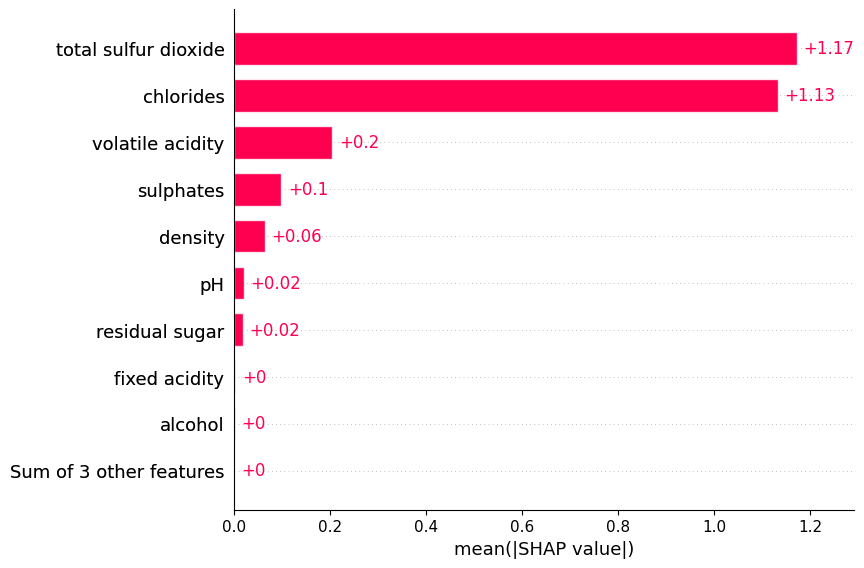

In [126]:
shap.plots.bar(shap_values)

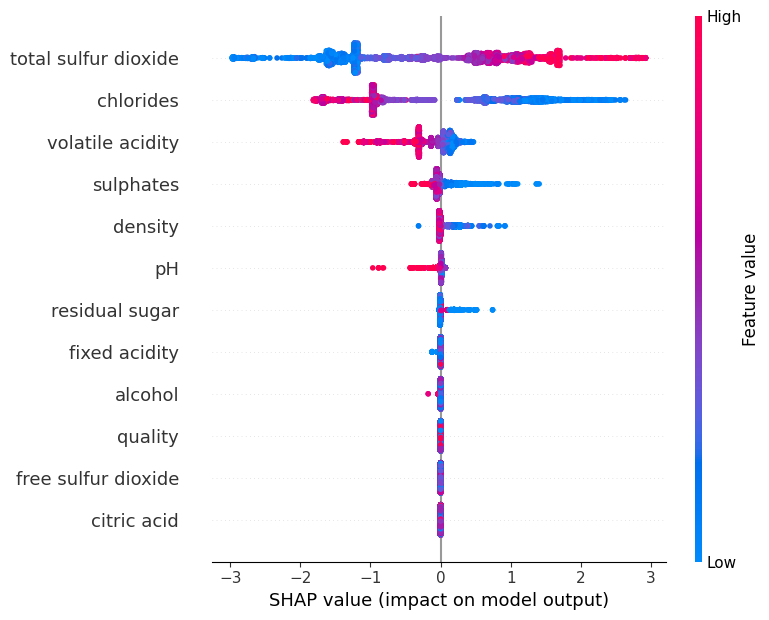

In [127]:
shap.summary_plot(shap_values, features=X_subtrain)

In [131]:
values = shap_values.values
shap_importance = np.abs(values).mean(axis=0)

feature_importance_shap = (pd.Series(shap_importance, index=feature_names).sort_values(ascending=False))

feature_importance_shap

total sulfur dioxide    1.171724
chlorides               1.132909
volatile acidity        0.204297
sulphates               0.097845
density                 0.063248
pH                      0.019858
residual sugar          0.018193
fixed acidity           0.002308
alcohol                 0.001247
citric acid             0.000000
free sulfur dioxide     0.000000
quality                 0.000000
dtype: float64

In [133]:
#Modelo 9: top-k SHAP
ks = range(1, X_trainN.shape[1] + 1)
results = []

for k in ks:
    topk = feature_importance_shap.index[:k]

    gb_k = GradientBoostingClassifier(n_estimators=20, random_state=32)
    gb_k.fit(X_subtrain[topk], y_subtrain)

    pred_val = gb_k.predict(X_val[topk])

    results.append({
        "k": k,
        "rasgos": list(topk),
        "accuracy_val": metrics.accuracy_score(y_val, pred_val),
        "f1_macro_val": metrics.f1_score(y_val, pred_val, average="macro")
    })

results_df = pd.DataFrame(results)
results_df

,k,rasgos,accuracy_val,f1_macro_val
0,1,[total sulfur dioxide],0.898585,0.898402
1,2,"[total sulfur dioxide, chlorides]",0.972877,0.972868
2,3,"[total sulfur dioxide, chlorides, volatile aci...",0.974646,0.974631
3,4,"[total sulfur dioxide, chlorides, volatile aci...",0.979953,0.979942
4,5,"[total sulfur dioxide, chlorides, volatile aci...",0.981132,0.981124
5,6,"[total sulfur dioxide, chlorides, volatile aci...",0.984080,0.984073
6,7,"[total sulfur dioxide, chlorides, volatile aci...",0.979953,0.979942
7,8,"[total sulfur dioxide, chlorides, volatile aci...",0.979953,0.979942
8,9,"[total sulfur dioxide, chlorides, volatile aci...",0.979953,0.979942
9,10,"[total sulfur dioxide, chlorides, volatile aci...",0.979953,0.979942


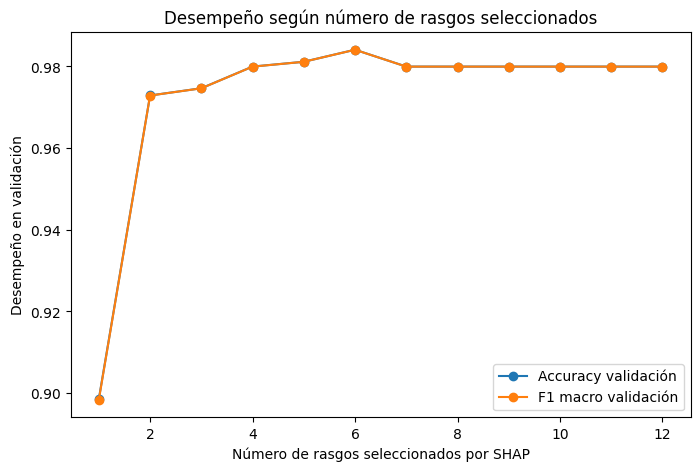

In [134]:
#Visualizacion grafica
plt.figure(figsize=(8, 5))
plt.plot(results_df["k"], results_df["accuracy_val"], marker="o", label="Accuracy validación")
plt.plot(results_df["k"], results_df["f1_macro_val"], marker="o", label="F1 macro validación")

plt.xlabel("Número de rasgos seleccionados por SHAP")
plt.ylabel("Desempeño en validación")
plt.title("Desempeño según número de rasgos seleccionados")
plt.legend()
plt.show()

In [136]:
best_row = results_df.sort_values(
    by=["f1_macro_val", "accuracy_val"], ascending=False
).iloc[0]

best_k = int(best_row["k"])
best_features = feature_importance_shap.index[:best_k]

print("Mejor k según validación:", best_k)
print("Rasgos seleccionados:", list(best_features))
print("F1 macro validación:", best_row["f1_macro_val"])
print("Accuracy validación:", best_row["accuracy_val"])

Mejor k según validación: 6
Rasgos seleccionados: ['total sulfur dioxide', 'chlorides', 'volatile acidity', 'sulphates', 'density', 'pH']
F1 macro validación: 0.9840734059059033
Accuracy validación: 0.9840801886792453


In [143]:
gb_final_shap = GradientBoostingClassifier(n_estimators=20, random_state=42)
gb_final_shap.fit(X_trainN[best_features], y_trainN)

pred_shap = gb_final_shap.predict(X_testN[best_features])

shap_acc = metrics.accuracy_score(y_testN, pred_shap)
shap_f1_macro = metrics.f1_score(y_testN, pred_shap, average="macro")

comparison_df = pd.DataFrame({
    "Método": ["Todos los rasgos", "SHAP top-k"],
    "Número de rasgos": [X_trainN.shape[1], len(best_features)],
    "Rasgos seleccionados": [list(feature_names), list(best_features)],
    "Accuracy prueba": [baseline_acc, shap_acc],
    "F1 macro prueba": [baseline_f1_macro, shap_f1_macro]
})

comparison_df

,Método,Número de rasgos,Rasgos seleccionados,Accuracy prueba,F1 macro prueba
0,Todos los rasgos,12,"[fixed acidity, volatile acidity, citric acid,...",0.983144,0.983120
1,SHAP top-k,6,"[total sulfur dioxide, chlorides, volatile aci...",0.984176,0.984153


In [137]:
#Modelo 10: Importancia acumulada con SHAP
cum_importance = (feature_importance_shap / feature_importance_shap.sum()).cumsum()
selected_by_cum = cum_importance[cum_importance <= 0.95].index

# Si el primer rasgo supera el umbral, se conserva al menos un rasgo.
if len(selected_by_cum) == 0:
    selected_by_cum = feature_importance_shap.index[:1]

print("Rasgos seleccionados por importancia acumulada:")
print(list(selected_by_cum))
print("Importancia acumulada:", cum_importance.loc[selected_by_cum[-1]])

Rasgos seleccionados por importancia acumulada:
['total sulfur dioxide', 'chlorides', 'volatile acidity']
Importancia acumulada: 0.9252483068267022


In [145]:
gb_cum = GradientBoostingClassifier(n_estimators=20, random_state=42)
gb_cum.fit(X_trainN[selected_by_cum], y_trainN)

pred_cum = gb_cum.predict(X_testN[selected_by_cum])

comparison_cum_df = pd.DataFrame({
    "Método": ["Todos los rasgos", "SHAP top-k", "SHAP 95% acumulado"],
    "Número de rasgos": [X_trainN.shape[1], len(best_features), len(selected_by_cum)],
    "Rasgos seleccionados": [list(feature_names), list(best_features), list(selected_by_cum)],
    "Accuracy prueba": [
        baseline_acc,
        shap_acc,
        metrics.accuracy_score(y_testN, pred_cum)
    ],
    "F1 macro prueba": [
        baseline_f1_macro,
        shap_f1_macro,
        metrics.f1_score(y_testN, pred_cum, average="macro")
    ]
})

comparison_cum_df


,Método,Número de rasgos,Rasgos seleccionados,Accuracy prueba,F1 macro prueba
0,Todos los rasgos,12,"[fixed acidity, volatile acidity, citric acid,...",0.983144,0.983120
1,SHAP top-k,6,"[total sulfur dioxide, chlorides, volatile aci...",0.984176,0.984153
2,SHAP 95% acumulado,3,"[total sulfur dioxide, chlorides, volatile aci...",0.978328,0.978299


In [146]:
if "benchmark_prev_df" in globals():
    shap_rows = comparison_cum_df[comparison_cum_df["Método"] != "Todos los rasgos"]

    benchmark_global_df = (
        pd.concat([benchmark_prev_df, shap_rows], ignore_index=True)
          .drop_duplicates(subset=["Método"], keep="last")
          .sort_values(by=["F1 macro prueba", "Accuracy prueba"], ascending=False)
          .reset_index(drop=True)
    )
else:
    benchmark_global_df = comparison_cum_df.sort_values(
        by=["F1 macro prueba", "Accuracy prueba"],
        ascending=False
    ).reset_index(drop=True)

benchmark_global_df

,Método,Número de rasgos,Rasgos seleccionados,Accuracy prueba,F1 macro prueba
0,L1 embebido,10,"[volatile acidity, citric acid, residual sugar...",0.984520,0.984498
1,Importancia Gradient Boosting,6,"[chlorides, total sulfur dioxide, volatile aci...",0.984176,0.984153
2,SHAP top-k,6,"[total sulfur dioxide, chlorides, volatile aci...",0.984176,0.984153
3,Todos los rasgos,12,"[fixed acidity, volatile acidity, citric acid,...",0.983144,0.983120
4,Forward Selection,10,"[fixed acidity, volatile acidity, citric acid,...",0.983144,0.983120
5,RFECV,11,"[fixed acidity, volatile acidity, residual sug...",0.983144,0.983120
6,SelectKBest ANOVA,7,"[total sulfur dioxide, volatile acidity, free ...",0.982456,0.982433
7,SelectKBest Chi2,8,"[total sulfur dioxide, free sulfur dioxide, vo...",0.981424,0.981398
8,Información mutua,8,"[chlorides, total sulfur dioxide, volatile aci...",0.981424,0.981398
9,SHAP 95% acumulado,3,"[total sulfur dioxide, chlorides, volatile aci...",0.978328,0.978299


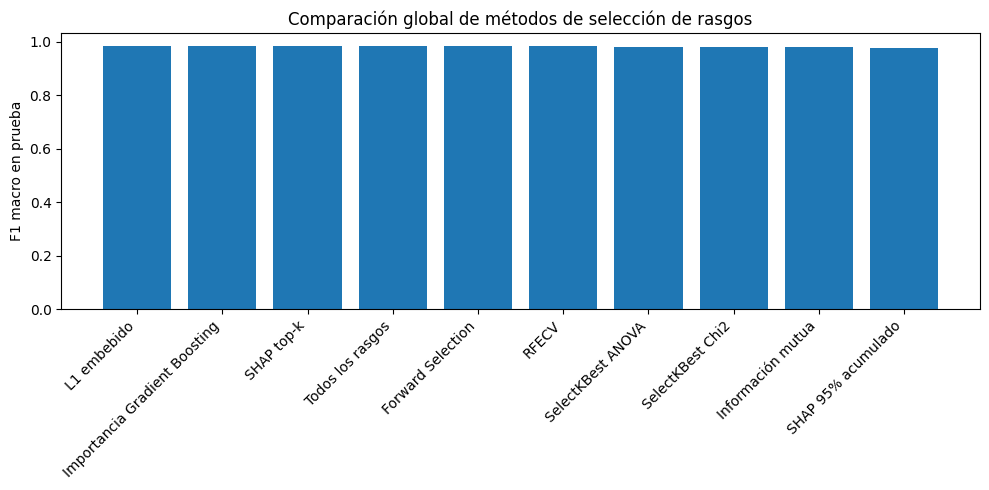

In [148]:
plt.figure(figsize=(10, 5))
plt.bar(benchmark_global_df["Método"], benchmark_global_df["F1 macro prueba"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 macro en prueba")
plt.title("Comparación global de métodos de selección de rasgos")
plt.tight_layout()
plt.show()

## ¿Qué rasgos seleccionar?

Todos dieron practicamente el mismo f1_score, entonces podemos definir que sea uno que use tantos pocos rasgos, y los rasgos mas representativos, mínimo:
- Total sulfur Dioxide
- chlorides
- volatile acidity

Posiblemente Importancia Gradient Boosting ó SHAP top-k. Revisaremos sus rasgos elegidos.

In [154]:
print("Rasgos seleccionados por Importancia Gradient Boosting")
list(benchmark_global_df[benchmark_global_df['Método'] == 'Importancia Gradient Boosting']['Rasgos seleccionados'])

Rasgos seleccionados por Importancia Gradient Boosting


[['chlorides',
  'total sulfur dioxide',
  'volatile acidity',
  'sulphates',
  'density',
  'pH']]

In [155]:
print("Rasgos seleccionados por Importancia Gradient Boosting")
list(benchmark_global_df[benchmark_global_df['Método'] == 'SHAP top-k']['Rasgos seleccionados'])

Rasgos seleccionados por Importancia Gradient Boosting


[['total sulfur dioxide',
  'chlorides',
  'volatile acidity',
  'sulphates',
  'density',
  'pH']]

Teniendo los mismos rasgos, seleccionamos SHAP top-k

## Reentreno de los 3 mejores modelos
Con esos rasgos, reentrenaremos los 3 mejores modelos para verificar si podemos mejorar el desempeño de clasificacion sin llegar al sobreajuste.